# Dataset Loading

In [ ]:
%%writefile download_ffpp.py
#!/usr/bin/env python
""" Downloads FaceForensics++ and Deep Fake Detection public data release
Example usage:
    see -h or https://github.com/ondyari/FaceForensics
"""
# -*- coding: utf-8 -*-
import argparse
import os
import urllib
import urllib.request
import tempfile
import time
import sys
import json
import random
from tqdm import tqdm
from os.path import join


# URLs and filenames
FILELIST_URL = 'misc/filelist.json'
DEEPFEAKES_DETECTION_URL = 'misc/deepfake_detection_filenames.json'
DEEPFAKES_MODEL_NAMES = ['decoder_A.h5', 'decoder_B.h5', 'encoder.h5',]

# Parameters
DATASETS = {
    'original_youtube_videos': 'misc/downloaded_youtube_videos.zip',
    'original_youtube_videos_info': 'misc/downloaded_youtube_videos_info.zip',
    'original': 'original_sequences/youtube',
    'DeepFakeDetection_original': 'original_sequences/actors',
    'Deepfakes': 'manipulated_sequences/Deepfakes',
    'DeepFakeDetection': 'manipulated_sequences/DeepFakeDetection',
    'Face2Face': 'manipulated_sequences/Face2Face',
    'FaceShifter': 'manipulated_sequences/FaceShifter',
    'FaceSwap': 'manipulated_sequences/FaceSwap',
    'NeuralTextures': 'manipulated_sequences/NeuralTextures'
    }
ALL_DATASETS = ['original', 'DeepFakeDetection_original', 'Deepfakes',
                'DeepFakeDetection', 'Face2Face', 'FaceShifter', 'FaceSwap',
                'NeuralTextures']
COMPRESSION = ['raw', 'c23', 'c40']
TYPE = ['videos', 'masks', 'models']
SERVERS = ['EU', 'EU2', 'CA']


def parse_args():
    parser = argparse.ArgumentParser(
        description='Downloads FaceForensics v2 public data release.',
        formatter_class=argparse.ArgumentDefaultsHelpFormatter
    )
    parser.add_argument('output_path', type=str, help='Output directory.')
    parser.add_argument('-d', '--dataset', type=str, default='all',
                        help='Which dataset to download, either pristine or '
                             'manipulated data or the downloaded youtube '
                             'videos.',
                        choices=list(DATASETS.keys()) + ['all']
                        )
    parser.add_argument('-c', '--compression', type=str, default='raw',
                        help='Which compression degree. All videos '
                             'have been generated with h264 with a varying '
                             'codec. Raw (c0) videos are lossless compressed.',
                        choices=COMPRESSION
                        )
    parser.add_argument('-t', '--type', type=str, default='videos',
                        help='Which file type, i.e. videos, masks, for our '
                             'manipulation methods, models, for Deepfakes.',
                        choices=TYPE
                        )
    parser.add_argument('-n', '--num_videos', type=int, default=None,
                        help='Select a number of videos number to '
                             "download if you don't want to download the full"
                             ' dataset.')
    parser.add_argument('--server', type=str, default='EU',
                        help='Server to download the data from. If you '
                             'encounter a slow download speed, consider '
                             'changing the server.',
                        choices=SERVERS
                        )
    args = parser.parse_args()

    # URLs
    server = args.server
    if server == 'EU':
        server_url = 'http://canis.vc.in.tum.de:8100/'
    elif server == 'EU2':
        server_url = 'http://kaldir.vc.in.tum.de/faceforensics/'
    elif server == 'CA':
        server_url = 'http://falas.cmpt.sfu.ca:8100/'
    else:
        raise Exception('Wrong server name. Choices: {}'.format(str(SERVERS)))
    args.tos_url = server_url + 'webpage/FaceForensics_TOS.pdf'
    args.base_url = server_url + 'v3/'
    args.deepfakes_model_url = server_url + 'v3/manipulated_sequences/' + \
                               'Deepfakes/models/'

    return args


def download_files(filenames, base_url, output_path, report_progress=True):
    os.makedirs(output_path, exist_ok=True)
    if report_progress:
        filenames = tqdm(filenames)
    for filename in filenames:
        download_file(base_url + filename, join(output_path, filename))


def reporthook(count, block_size, total_size):
    global start_time
    if count == 0:
        start_time = time.time()
        return
    duration = time.time() - start_time
    progress_size = int(count * block_size)
    speed = int(progress_size / (1024 * duration))
    percent = int(count * block_size * 100 / total_size)
    sys.stdout.write("\rProgress: %d%%, %d MB, %d KB/s, %d seconds passed" %
                     (percent, progress_size / (1024 * 1024), speed, duration))
    sys.stdout.flush()


def download_file(url, out_file, report_progress=False):
    out_dir = os.path.dirname(out_file)
    if not os.path.isfile(out_file):
        fh, out_file_tmp = tempfile.mkstemp(dir=out_dir)
        f = os.fdopen(fh, 'w')
        f.close()
        if report_progress:
            urllib.request.urlretrieve(url, out_file_tmp,
                                       reporthook=reporthook)
        else:
            urllib.request.urlretrieve(url, out_file_tmp)
        os.rename(out_file_tmp, out_file)
    else:
        tqdm.write('WARNING: skipping download of existing file ' + out_file)


def main(args):
    # TOS
    print('By pressing any key to continue you confirm that you have agreed '\
          'to the FaceForensics terms of use as described at:')
    print(args.tos_url)
    print('***')
    print('Press any key to continue, or CTRL-C to exit.')
    _ = input('')

    # Extract arguments
    c_datasets = [args.dataset] if args.dataset != 'all' else ALL_DATASETS
    c_type = args.type
    c_compression = args.compression
    num_videos = args.num_videos
    output_path = args.output_path
    os.makedirs(output_path, exist_ok=True)

    # Check for special dataset cases
    for dataset in c_datasets:
        dataset_path = DATASETS[dataset]
        # Special cases
        if 'original_youtube_videos' in dataset:
            # Here we download the original youtube videos zip file
            print('Downloading original youtube videos.')
            if not 'info' in dataset_path:
                print('Please be patient, this may take a while (~40gb)')
                suffix = ''
            else:
            	suffix = 'info'
            download_file(args.base_url + '/' + dataset_path,
                          out_file=join(output_path,
                                        'downloaded_videos{}.zip'.format(
                                            suffix)),
                          report_progress=True)
            return

        # Else: regular datasets
        print('Downloading {} of dataset "{}"'.format(
            c_type, dataset_path
        ))

        # Get filelists and video lenghts list from server
        if 'DeepFakeDetection' in dataset_path or 'actors' in dataset_path:
        	filepaths = json.loads(urllib.request.urlopen(args.base_url + '/' +
                DEEPFEAKES_DETECTION_URL).read().decode("utf-8"))
        	if 'actors' in dataset_path:
        		filelist = filepaths['actors']
        	else:
        		filelist = filepaths['DeepFakesDetection']
        elif 'original' in dataset_path:
            # Load filelist from server
            file_pairs = json.loads(urllib.request.urlopen(args.base_url + '/' +
                FILELIST_URL).read().decode("utf-8"))
            filelist = []
            for pair in file_pairs:
            	filelist += pair
        else:
            # Load filelist from server
            file_pairs = json.loads(urllib.request.urlopen(args.base_url + '/' +
                FILELIST_URL).read().decode("utf-8"))
            # Get filelist
            filelist = []
            for pair in file_pairs:
                filelist.append('_'.join(pair))
                if c_type != 'models':
                    filelist.append('_'.join(pair[::-1]))
        # Maybe limit number of videos for download
        if num_videos is not None and num_videos > 0:
        	print('Downloading the first {} videos'.format(num_videos))
        	filelist = filelist[:num_videos]

        # Server and local paths
        dataset_videos_url = args.base_url + '{}/{}/{}/'.format(
            dataset_path, c_compression, c_type)
        dataset_mask_url = args.base_url + '{}/{}/videos/'.format(
            dataset_path, 'masks', c_type)

        if c_type == 'videos':
            dataset_output_path = join(output_path, dataset_path, c_compression,
                                       c_type)
            print('Output path: {}'.format(dataset_output_path))
            filelist = [filename + '.mp4' for filename in filelist]
            download_files(filelist, dataset_videos_url, dataset_output_path)
        elif c_type == 'masks':
            dataset_output_path = join(output_path, dataset_path, c_type,
                                       'videos')
            print('Output path: {}'.format(dataset_output_path))
            if 'original' in dataset:
                if args.dataset != 'all':
                    print('Only videos available for original data. Aborting.')
                    return
                else:
                    print('Only videos available for original data. '
                          'Skipping original.\n')
                    continue
            if 'FaceShifter' in dataset:
                print('Masks not available for FaceShifter. Aborting.')
                return
            filelist = [filename + '.mp4' for filename in filelist]
            download_files(filelist, dataset_mask_url, dataset_output_path)

        # Else: models for deepfakes
        else:
            if dataset != 'Deepfakes' and c_type == 'models':
                print('Models only available for Deepfakes. Aborting')
                return
            dataset_output_path = join(output_path, dataset_path, c_type)
            print('Output path: {}'.format(dataset_output_path))

            # Get Deepfakes models
            for folder in tqdm(filelist):
                folder_filelist = DEEPFAKES_MODEL_NAMES

                # Folder paths
                folder_base_url = args.deepfakes_model_url + folder + '/'
                folder_dataset_output_path = join(dataset_output_path,
                                                  folder)
                download_files(folder_filelist, folder_base_url,
                               folder_dataset_output_path,
                               report_progress=False)   # already done


if __name__ == "__main__":
    args = parse_args()
    main(args)

Writing download_ffpp.py


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
mkdir -p /content/drive/MyDrive/FaceForensics++


In [ ]:
cd /content/drive/MyDrive/FaceForensics++


/content/drive/MyDrive/FaceForensics++


In [ ]:
!python download_ffpp.py FaceForensics++ \
    -d original \
    -c c23 \
    -t videos \
    -n 120 \
    --server EU2

By pressing any key to continue you confirm that you have agreed to the FaceForensics terms of use as described at:
http://kaldir.vc.in.tum.de/faceforensics/webpage/FaceForensics_TOS.pdf
***
Press any key to continue, or CTRL-C to exit.
J
Output path: FaceForensics++/original_sequences/youtube/c23/videos
100% 120/120 [03:42<00:00,  1.86s/it]


In [ ]:
!python download_ffpp.py FaceForensics++ \
    -d Deepfakes \
    -c c23 \
    -t videos \
    -n 120 \
    --server EU2

By pressing any key to continue you confirm that you have agreed to the FaceForensics terms of use as described at:
http://kaldir.vc.in.tum.de/faceforensics/webpage/FaceForensics_TOS.pdf
***
Press any key to continue, or CTRL-C to exit.
J
Output path: FaceForensics++/manipulated_sequences/Deepfakes/c23/videos
100% 120/120 [03:41<00:00,  1.84s/it]


In [ ]:
!python download_ffpp.py FaceForensics++ \
    -d Face2Face \
    -c c23 \
    -t videos \
    -n 120 \
    --server EU2


By pressing any key to continue you confirm that you have agreed to the FaceForensics terms of use as described at:
http://kaldir.vc.in.tum.de/faceforensics/webpage/FaceForensics_TOS.pdf
***
Press any key to continue, or CTRL-C to exit.
J
Output path: FaceForensics++/manipulated_sequences/Face2Face/c23/videos
100% 120/120 [03:37<00:00,  1.81s/it]


In [ ]:
!python download_ffpp.py FaceForensics++ \
    -d FaceSwap \
    -c c23 \
    -t videos \
    -n 120 \
    --server EU2


By pressing any key to continue you confirm that you have agreed to the FaceForensics terms of use as described at:
http://kaldir.vc.in.tum.de/faceforensics/webpage/FaceForensics_TOS.pdf
***
Press any key to continue, or CTRL-C to exit.
J
Output path: FaceForensics++/manipulated_sequences/FaceSwap/c23/videos
100% 120/120 [03:37<00:00,  1.81s/it]


In [ ]:
!python download_ffpp.py FaceForensics++ \
    -d NeuralTextures \
    -c c23 \
    -t videos \
    -n 120 \
    --server EU2


By pressing any key to continue you confirm that you have agreed to the FaceForensics terms of use as described at:
http://kaldir.vc.in.tum.de/faceforensics/webpage/FaceForensics_TOS.pdf
***
Press any key to continue, or CTRL-C to exit.
J
Output path: FaceForensics++/manipulated_sequences/NeuralTextures/c23/videos
100% 120/120 [03:28<00:00,  1.73s/it]


Set directories

In [ ]:
import os, glob
from collections import defaultdict

REAL_DIR = "FaceForensics++/original_sequences/youtube/c23/videos"
MANIP_DIR = "FaceForensics++/manipulated_sequences"

methods = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]

real_map = {
    os.path.splitext(os.path.basename(p))[0]: p
    for p in glob.glob(f"{REAL_DIR}/*.mp4")
}

pairs_by_method = defaultdict(list)

for m in methods:
    fake_paths = glob.glob(f"{MANIP_DIR}/{m}/c23/videos/*.mp4")
    for fp in fake_paths:
        name = os.path.splitext(os.path.basename(fp))[0]  # e.g. 000_001
        if "_" not in name:
            continue
        a, b = name.split("_")
        if a in real_map and b in real_map:
            pairs_by_method[m].append((fp, real_map[a], real_map[b]))

for m in methods:
    print(m, "pairs:", len(pairs_by_method[m]))


Deepfakes pairs: 120
Face2Face pairs: 120
FaceSwap pairs: 120
NeuralTextures pairs: 120


# Imports and installation

In [ ]:

import cv2, numpy as np, torch
from tqdm import tqdm
from scipy.stats import kurtosis, ks_2samp
import matplotlib.pyplot as plt

import torchvision.models as models
import torchvision.transforms as T

In [ ]:
!pip -q install facenet-pytorch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
!pip install -U --quiet \
  torch==2.1.2 \
  torchvision==0.16.2 \
  torchaudio==2.1.2 \
  facenet-pytorch==2.5.3 \
  numpy==1.24.4 \
  opencv-python-headless==4.8.1.78 \
  scipy \
  tqdm \
  matplotlib

ERROR: Could not find a version that satisfies the requirement torch==2.1.2 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1)
ERROR: No matching distribution found for torch==2.1.2


In [ ]:
from facenet_pytorch import MTCNN

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

mtcnn = MTCNN(
    image_size=160,     # face crop size
    margin=20,          # helps include jaw/forehead
    select_largest=True,
    post_process=True,
    device=device
)
print("Detector device:", device)


Detector device: cpu


# Feature Extraction

Face extraction utils function using MTCNN

In [ ]:
def extract_face_crops(frames, min_faces=18):
    """
    frames: (T,H,W,3) RGB
    returns: list of face crops as RGB numpy arrays (160x160x3)
    """
    faces = []
    for f in frames:
        # MTCNN expects PIL or numpy RGB; returns torch tensor CHW or None
        face = mtcnn(f)
        if face is not None:
            # face is torch tensor (3,160,160) in [0,1]
            face_np = (face.permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)
            faces.append(face_np)

    if len(faces) < min_faces:
        return None
    return faces


Image Embedder

In [ ]:
embedder = models.resnet18(weights="IMAGENET1K_V1")
embedder.fc = torch.nn.Identity()
embedder.eval().to(device)

face_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((224,224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406],
                std=[0.229,0.224,0.225])
])


Uniformly sample a fixed number of frames from a video to create a temporally representative snapshot of its content.

In [ ]:
import cv2, numpy as np

def sample_frames(video_path, num_frames=24):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < num_frames or total <= 0:
        cap.release()
        return None

    idxs = set(np.linspace(0, total - 1, num_frames).astype(int))
    frames = []
    i = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if i in idxs:
            frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        i += 1
    cap.release()
    return np.stack(frames) if len(frames) == num_frames else None


Test the function and show triplet example

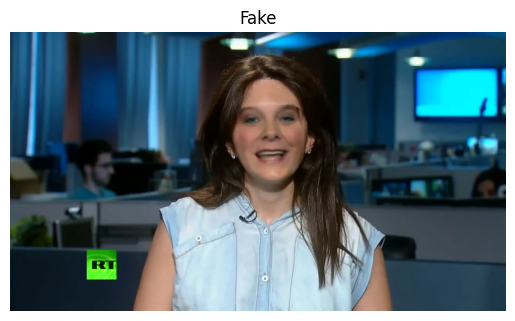

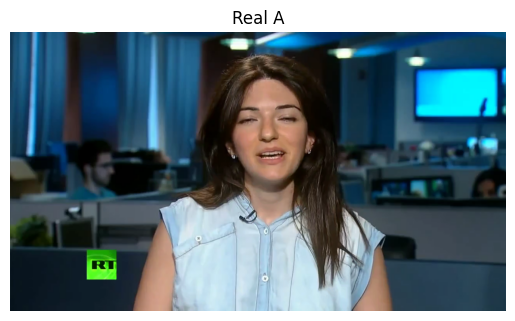

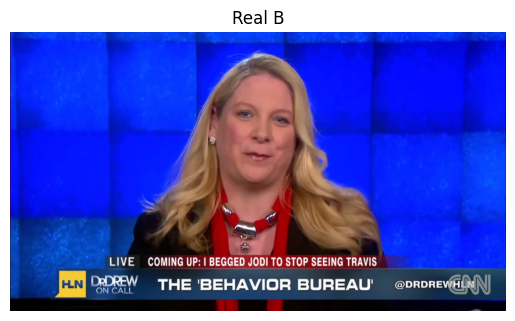

In [ ]:
import matplotlib.pyplot as plt

def show_triplet(fake, realA, realB):
    for title, path in [("Fake", fake), ("Real A", realA), ("Real B", realB)]:
        frames = sample_frames(path, num_frames=1)
        plt.figure()
        plt.imshow(frames[0])
        plt.title(title)
        plt.axis("off")
        plt.show()

show_triplet(*pairs_by_method["Deepfakes"][0])


Detects a face once and consistently extracts both face and background regions across all frames in a video clip.
Use MTCNN to locate the first detectable face, fix the bounding box, and apply it to every frame to generate aligned face crops and corresponding background-only images.

In [ ]:
def extract_face_and_bg(frames, min_frames=18):
    first_box = None
    for f in frames:
        boxes, _ = mtcnn.detect(f)
        if boxes is not None and len(boxes) > 0:
            first_box = boxes[0]
            break
    if first_box is None:
        return None, None

    x1,y1,x2,y2 = map(int, first_box)
    face_crops, bg_crops = [], []

    for f in frames:
        H,W,_ = f.shape
        x1c,y1c = max(0,x1), max(0,y1)
        x2c,y2c = min(W,x2), min(H,y2)

        face = f[y1c:y2c, x1c:x2c]
        if face.size == 0:
            continue
        face = cv2.resize(face, (160,160))

        bg = f.copy()
        bg[y1c:y2c, x1c:x2c] = 0
        bg = cv2.resize(bg, (160,160))

        face_crops.append(face)
        bg_crops.append(bg)

    if len(face_crops) < min_frames:
        return None, None

    return face_crops, bg_crops


In [ ]:
from facenet_pytorch import InceptionResnetV1
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

embedder = InceptionResnetV1(pretrained="vggface2").eval().to(device)


Standardizes input images by converting raw image arrays into normalized tensors.

In [ ]:
import torchvision.transforms as T

transform = T.Compose([
    T.ToPILImage(),
    T.Resize((160,160)),
    T.ToTensor(),
    T.Normalize(mean=[0.5,0.5,0.5],
                std=[0.5,0.5,0.5])
])


Extracts temporal inconsistency features from a sequence of image crops by analyzing how deep feature embeddings change over time.

In [ ]:
from scipy.stats import kurtosis
from scipy.signal import correlate
from scipy.fft import fft

def temporal_descriptors(crops):
    x = torch.stack([transform(f) for f in crops]).to(device)
    with torch.no_grad():
        z = embedder(x).cpu().numpy()

    deltas = np.linalg.norm(z[1:] - z[:-1], axis=1)

    ac = correlate(deltas - deltas.mean(), deltas - deltas.mean(), mode="full")
    ac_lag1 = ac[len(ac)//2 + 1] / ac[len(ac)//2]

    spectrum = np.abs(fft(deltas))
    freqs = np.arange(len(spectrum))
    centroid = (freqs * spectrum).sum() / (spectrum.sum() + 1e-6)

    return [
        deltas.mean(),
        deltas.var(),
        kurtosis(deltas),
        ac_lag1,
        centroid
    ]


Compute a relative feature difference between a fake sample and its corresponding real references.

In [ ]:
def paired_delta(fake_feat, realA_feat, realB_feat):
    return np.array(fake_feat) - 0.5 * (np.array(realA_feat) + np.array(realB_feat))


Extracts pixel-level temporal inconsistency features by measuring frame-to-frame appearance changes in a sequence of face crops.
Compute absolute pixel differences between consecutive frames and summarize both their magnitude and frequency characteristics.

In [ ]:
def pixel_temporal_features(face_crops):
    diffs = []
    for i in range(len(face_crops) - 1):
        f1 = face_crops[i].astype(np.float32)
        f2 = face_crops[i+1].astype(np.float32)
        diff = np.abs(f2 - f1)
        diffs.append(diff.mean())

    diffs = np.array(diffs)

    spectrum = np.abs(np.fft.fft(diffs))
    high_freq_energy = spectrum[len(spectrum)//2:].mean()

    return [
        diffs.mean(),
        diffs.var(),
        np.percentile(diffs, 95),
        high_freq_energy
    ]


constructs a relative temporal “fingerprint” for a manipulated video by comparing its temporal dynamics to those of corresponding real reference videos.
It computes temporal descriptors for the fake sequence and subtracts the average descriptors of two authentic sequences.

In [ ]:
def paired_fingerprint(fake, origA, origB):
    f_fake = temporal_descriptors(fake)
    f_orig = 0.5 * (np.array(temporal_descriptors(origA)) +
                    np.array(temporal_descriptors(origB)))
    return np.array(f_fake) - f_orig


Extracts frequency-domain energy statistics from face images by analyzing their 2D Fourier spectrum.
For each face crop, it computes the spatial frequency distribution and summarizes energy across low, mid, and high frequency bands.

In [ ]:
import numpy as np
import cv2

def fft_band_energy(face_crops):
    """
    face_crops: list of RGB face crops (160x160x3)
    returns: vector of frequency energy stats
    """
    energies = []

    for f in face_crops:
        gray = cv2.cvtColor(f, cv2.COLOR_RGB2GRAY)
        F = np.fft.fftshift(np.fft.fft2(gray))
        mag = np.log(np.abs(F) + 1e-8)

        h, w = mag.shape
        cy, cx = h // 2, w // 2

        r = np.sqrt((np.arange(h)[:, None] - cy) ** 2 +
                    (np.arange(w)[None, :] - cx) ** 2)
        r = r / r.max()

        low = mag[r < 0.2].mean()
        mid = mag[(r >= 0.2) & (r < 0.5)].mean()
        high = mag[r >= 0.5].mean()

        energies.append([low, mid, high])

    energies = np.array(energies)

    return np.concatenate([
        energies.mean(axis=0),
        energies.std(axis=0)
    ])


Approximates facial landmark instability over time by tracking the motion of edge-based centroids across consecutive face frames.
Instead of explicit landmark detectors, it uses edge detection to provide a lightweight, dependency-free proxy for geometric jitter.

In [ ]:
import cv2
import numpy as np

def landmark_jitter_features(face_crops):
    """
    Temporal geometric jitter proxy using edge centroid instability.
    No MediaPipe, no dlib, Python 3.12 safe.
    """

    centroids = []

    for f in face_crops:
        gray = cv2.cvtColor(f, cv2.COLOR_RGB2GRAY)

        # Edge detection
        edges = cv2.Canny(gray, 50, 150)

        ys, xs = np.where(edges > 0)

        # Skip frames with too few edges
        if len(xs) < 100:
            continue

        cx = xs.mean()
        cy = ys.mean()

        centroids.append([cx, cy])

    # Not enough valid frames
    if len(centroids) < 5:
        return np.zeros(8)

    centroids = np.array(centroids)  # T x 2

    diffs = np.diff(centroids, axis=0)
    dists = np.linalg.norm(diffs, axis=1)

    return np.array([
        dists.mean(),
        dists.std(),
        dists.max(),
        np.percentile(dists, 90),
        np.percentile(dists, 95),
        np.mean(np.abs(np.diff(dists))),
        np.std(np.abs(np.diff(dists))),
        dists.var()
    ])


Measures temporal inconsistency using optical flow alignment error between consecutive face frames.
It estimates pixel motion with dense optical flow, warps one frame toward the next, and quantifies how well the motion-compensated frame matches the actual observation.

In [ ]:
def flow_warp_residual(face_crops):
    """
    Measures temporal inconsistency using optical flow
    """
    residuals = []

    for i in range(len(face_crops) - 1):
        f1 = cv2.cvtColor(face_crops[i], cv2.COLOR_RGB2GRAY)
        f2 = cv2.cvtColor(face_crops[i+1], cv2.COLOR_RGB2GRAY)

        flow = cv2.calcOpticalFlowFarneback(
            f1, f2,
            None,
            pyr_scale=0.5,
            levels=3,
            winsize=15,
            iterations=3,
            poly_n=5,
            poly_sigma=1.2,
            flags=0
        )

        h, w = f1.shape
        grid_x, grid_y = np.meshgrid(np.arange(w), np.arange(h))
        map_x = (grid_x + flow[..., 0]).astype(np.float32)
        map_y = (grid_y + flow[..., 1]).astype(np.float32)

        warped = cv2.remap(f1, map_x, map_y, cv2.INTER_LINEAR)
        residuals.append(np.mean(np.abs(warped - f2)))

    if len(residuals) == 0:
        return np.zeros(4)

    residuals = np.array(residuals)

    return np.array([
        residuals.mean(),
        residuals.std(),
        residuals.max(),
        np.percentile(residuals, 95)
    ])


Feature Extraction Loop - Only the *temproal* features

In [ ]:
from tqdm import tqdm
import numpy as np

# New feature matrices
X_fft = []
X_landmark = []
X_flow = []

y = []
meta = []   # optional

for m in methods:
    print(f"Processing {m}")
    for fake_path, a_path, b_path in tqdm(
        pairs_by_method[m],
        desc=m,
        leave=False
    ):
        # --- Sample frames ---
        frames_f = sample_frames(fake_path)
        if frames_f is None:
            continue

        # --- Extract face only ---
        face_f, _ = extract_face_and_bg(frames_f)
        if face_f is None:
            continue

        # ===============================
        # New artifact-oriented features
        # ===============================

        # FFT frequency-band energy
        fft_feat = fft_band_energy(face_f)

        # Landmark temporal jitter
        landmark_feat = landmark_jitter_features(face_f)

        # Optical-flow temporal inconsistency
        flow_feat = flow_warp_residual(face_f)

        # ===============================
        # Save
        # ===============================

        X_fft.append(fft_feat)
        X_landmark.append(landmark_feat)
        X_flow.append(flow_feat)

        y.append(m)
        meta.append(fake_path)


Processing Deepfakes


Processing Face2Face


Processing FaceSwap


Processing NeuralTextures


Saving and loading the processed files into google drive

In [ ]:
import os
import numpy as np

CACHE_DIR = "/content/drive/MyDrive/FaceForensics++"
os.makedirs(CACHE_DIR, exist_ok=True)

CACHE_FILE = os.path.join(CACHE_DIR, "artifact_features.npz")

np.savez_compressed(
    CACHE_FILE,
    X_fft=X_fft,
    X_landmark=X_landmark,
    X_flow=X_flow,
    y=y,
    meta=np.array(meta, dtype=object)
)

print("Saved artifact-only features to", CACHE_FILE)


Saved artifact-only features to /content/drive/MyDrive/FaceForensics++/artifact_features.npz


Feature Extraction Loop - Only the *Embeddings* features

In [ ]:
from tqdm import tqdm

X_face_embed = []
X_bg_embed = []
X_pixel = []
y = []
meta = []   # optional: keep paths if needed

for m in methods:
    print(f"Processing {m}")
    for fake_path, a_path, b_path in tqdm(
        pairs_by_method[m],
        desc=m,
        leave=False
    ):
        # --- Sample frames ---
        frames_f = sample_frames(fake_path)
        frames_a = sample_frames(a_path)
        frames_b = sample_frames(b_path)

        if frames_f is None or frames_a is None or frames_b is None:
            continue

        # --- Extract face & background ---
        face_f, bg_f = extract_face_and_bg(frames_f)
        face_a, bg_a = extract_face_and_bg(frames_a)
        face_b, bg_b = extract_face_and_bg(frames_b)

        if None in (face_f, face_a, face_b, bg_f, bg_a, bg_b):
            continue

        # --- Face embedding temporal ---
        fe_f = temporal_descriptors(face_f)
        fe_a = temporal_descriptors(face_a)
        fe_b = temporal_descriptors(face_b)
        face_embed_delta = paired_delta(fe_f, fe_a, fe_b)

        # --- Background embedding temporal ---
        be_f = temporal_descriptors(bg_f)
        be_a = temporal_descriptors(bg_a)
        be_b = temporal_descriptors(bg_b)
        bg_embed_delta = paired_delta(be_f, be_a, be_b)

        # --- Pixel temporal (face only) ---
        px_f = pixel_temporal_features(face_f)
        px_a = pixel_temporal_features(face_a)
        px_b = pixel_temporal_features(face_b)
        pixel_delta = paired_delta(px_f, px_a, px_b)

        # --- Save ---
        X_face_embed.append(face_embed_delta)
        X_bg_embed.append(bg_embed_delta)
        X_pixel.append(pixel_delta)
        y.append(m)
        meta.append((fake_path, a_path, b_path))

# Convert to arrays
X_face_embed = np.array(X_face_embed)
X_bg_embed = np.array(X_bg_embed)
X_pixel = np.array(X_pixel)
y = np.array(y)

print("Face embed:", X_face_embed.shape)
print("BG embed:", X_bg_embed.shape)
print("Pixel:", X_pixel.shape)


Processing Deepfakes


Processing Face2Face


Processing FaceSwap


Processing NeuralTextures


Face embed: (480, 5)
BG embed: (480, 5)
Pixel: (480, 4)


In [ ]:
import os, numpy as np

CACHE_DIR = "/content/drive/MyDrive/FaceForensics++"
os.makedirs(CACHE_DIR, exist_ok=True)

CACHE_FILE = os.path.join(CACHE_DIR, "features.npz")

np.savez_compressed(
    CACHE_FILE,
    X_face_embed=X_face_embed,
    X_bg_embed=X_bg_embed,
    X_pixel=X_pixel,
    y=y,
    meta=np.array(meta, dtype=object)
)

print("Saved to", CACHE_FILE)


Saved to /content/drive/MyDrive/FaceForensics++/features.npz


In [67]:
import os, numpy as np


CACHE_DIR = "/content/drive/MyDrive/FaceForensics++"

CACHE_FILE = os.path.join(CACHE_DIR, "features.npz")


if os.path.exists(CACHE_FILE):
    data = np.load(CACHE_FILE, allow_pickle=True)
    X_face_embed = data["X_face_embed"]
    X_bg_embed   = data["X_bg_embed"]
    X_pixel      = data["X_pixel"]
    y            = data["y"]
    meta         = data["meta"]
    print("Loaded cached features")


Loaded cached features


In [68]:
import os, numpy as np


CACHE_DIR = "/content/drive/MyDrive/FaceForensics++"

CACHE_FILE = os.path.join(CACHE_DIR, "artifact_features.npz")


if os.path.exists(CACHE_FILE):
    data = np.load(CACHE_FILE, allow_pickle=True)
    X_fft = data["X_fft"]
    X_landmark   = data["X_landmark"]
    X_flow      = data["X_flow"]
    y            = data["y"]
    meta         = data["meta"]
    print("Loaded cached features")


Loaded cached features


In [69]:
X_fft = np.array(X_fft)
X_landmark = np.array(X_landmark)
X_flow = np.array(X_flow)
y = np.array(y)

print("FFT:", X_fft.shape)
print("Landmark:", X_landmark.shape)
print("Flow:", X_flow.shape)
print("Labels:", y.shape)


FFT: (480, 6)
Landmark: (480, 8)
Flow: (480, 4)
Labels: (480,)


# Evaluation and Results

In [71]:
methods = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]


In [72]:
feature_sets = {
    "fft": X_fft,
    "landmark": X_landmark,
    "flow": X_flow,
    "face": np.array(X_face_embed),
    "bg": np.array(X_bg_embed),
    "pixel": np.array(X_pixel),

}


In [73]:
import numpy as np

def make_binary_labels(y, positive_class):
    """
    One-vs-rest binary labels
    """
    return (np.array(y) == positive_class).astype(int)


Load classifiers

In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

try:
    from xgboost import XGBClassifier
    has_xgb = True
except ImportError:
    has_xgb = False

classifiers = {
    "RF": RandomForestClassifier(
        n_estimators=150,
        max_depth=None,
        random_state=0,
        n_jobs=-1
    ),
    "SVM": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale"
    )
}

if has_xgb:
    classifiers["XGB"] = XGBClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        tree_method="hist",
        random_state=0
    )


One-vs-All binary classification using 10-fold stratified cross-validation.
In each iteration, one manipulation method is treated as the positive class, while all other methods are grouped as the negative class.
Each feature set and classifier is evaluated independently using ROC-AUC as the performance metric.

In [75]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

results = []

for method in methods:
    y_bin = make_binary_labels(y, method)

    for feat_name, X in feature_sets.items():
        for clf_name, clf in classifiers.items():
            scores = cross_val_score(
                clf,
                X,
                y_bin,
                cv=cv,
                scoring="roc_auc",
                n_jobs=-1
            )

            results.append({
                "method": method,
                "features": feat_name,
                "model": clf_name,
                "acc_mean": scores.mean(),
                "acc_std": scores.std()
            })

            print(
                f"[{method:15s}] "
                f"{feat_name:7s} | "
                f"{clf_name:4s} → "
                f"{scores.mean():.3f} ± {scores.std():.3f}"
            )


[Deepfakes      ] fft     | RF   → 0.512 ± 0.103
[Deepfakes      ] fft     | SVM  → 0.532 ± 0.093
[Deepfakes      ] fft     | XGB  → 0.515 ± 0.087
[Deepfakes      ] landmark | RF   → 0.502 ± 0.091
[Deepfakes      ] landmark | SVM  → 0.498 ± 0.092
[Deepfakes      ] landmark | XGB  → 0.485 ± 0.108
[Deepfakes      ] flow    | RF   → 0.564 ± 0.078
[Deepfakes      ] flow    | SVM  → 0.508 ± 0.098
[Deepfakes      ] flow    | XGB  → 0.569 ± 0.091
[Deepfakes      ] face    | RF   → 0.553 ± 0.073
[Deepfakes      ] face    | SVM  → 0.575 ± 0.060
[Deepfakes      ] face    | XGB  → 0.546 ± 0.077
[Deepfakes      ] bg      | RF   → 0.506 ± 0.061
[Deepfakes      ] bg      | SVM  → 0.526 ± 0.059
[Deepfakes      ] bg      | XGB  → 0.526 ± 0.060
[Deepfakes      ] pixel   | RF   → 0.584 ± 0.112
[Deepfakes      ] pixel   | SVM  → 0.578 ± 0.076
[Deepfakes      ] pixel   | XGB  → 0.596 ± 0.091
[Face2Face      ] fft     | RF   → 0.389 ± 0.101
[Face2Face      ] fft     | SVM  → 0.520 ± 0.094
[Face2Face      ]

In [76]:
import pandas as pd

df = pd.DataFrame(results)
df.sort_values(
    by=["method", "acc_mean"],
    ascending=[True, False],
    inplace=True
)

df


,method,features,model,acc_mean,acc_std
17,Deepfakes,pixel,XGB,0.595602,0.091434
15,Deepfakes,pixel,RF,0.583681,0.112156
16,Deepfakes,pixel,SVM,0.578009,0.075514
10,Deepfakes,face,SVM,0.575000,0.059821
8,Deepfakes,flow,XGB,0.568981,0.090974
...,...,...,...,...,...
67,NeuralTextures,bg,SVM,0.428009,0.089410
68,NeuralTextures,bg,XGB,0.421528,0.072815
71,NeuralTextures,pixel,XGB,0.417130,0.087968
66,NeuralTextures,bg,RF,0.385185,0.082780


In [77]:
import numpy as np
import matplotlib.pyplot as plt

def plot_method_bars(df):
    methods = df["method"].unique()
    features = df["features"].unique()
    models = df["model"].unique()

    for method in methods:
        df_m = df[df["method"] == method]

        x = np.arange(len(features))
        width = 0.8 / len(models)

        plt.figure(figsize=(12, 6))

        for i, model in enumerate(models):
            means = []
            stds = []

            for feat in features:
                row = df_m[
                    (df_m["features"] == feat) &
                    (df_m["model"] == model)
                ]

                if len(row) == 0:
                    means.append(np.nan)
                    stds.append(0)
                else:
                    means.append(row["acc_mean"].values[0])
                    stds.append(row["acc_std"].values[0])

            plt.bar(
                x + i * width,
                means,
                width,
                yerr=stds,
                capsize=4,
                label=model,
                edgecolor="black"
            )

        plt.xticks(x + width * (len(models) - 1) / 2, features, rotation=20)
        plt.ylabel("ROC-AUC")
        plt.ylim(0.4, 1.0)
        plt.title(f"One-vs-All ROC-AUC — Method: {method}")
        plt.legend(title="Model")
        plt.grid(axis="y", linestyle="--", alpha=0.4)

        plt.tight_layout()
        plt.show()


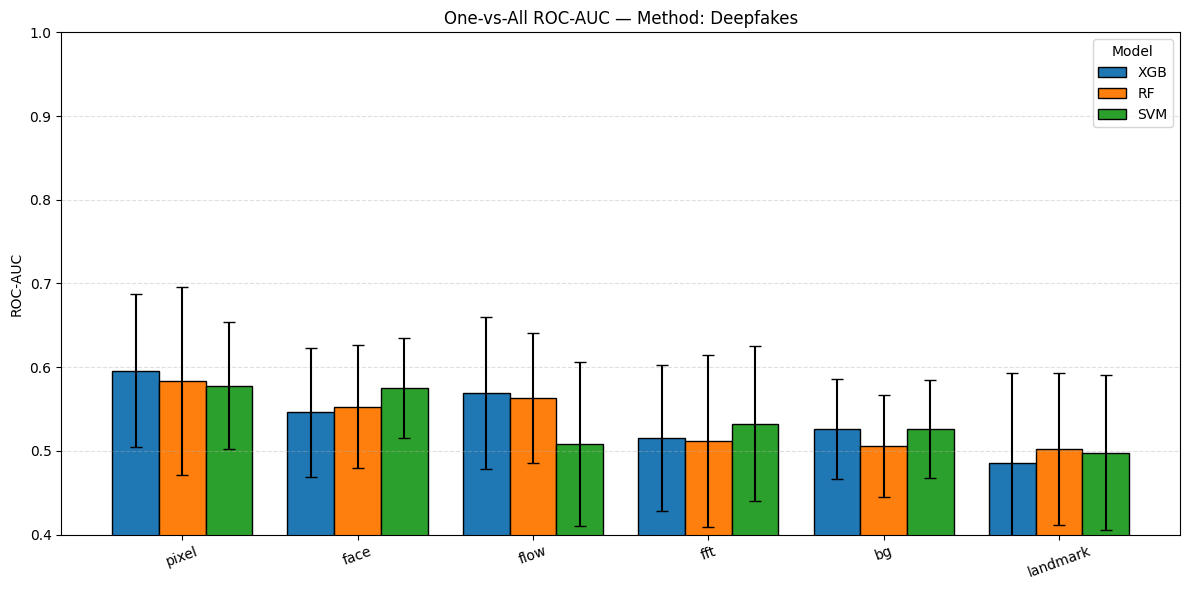

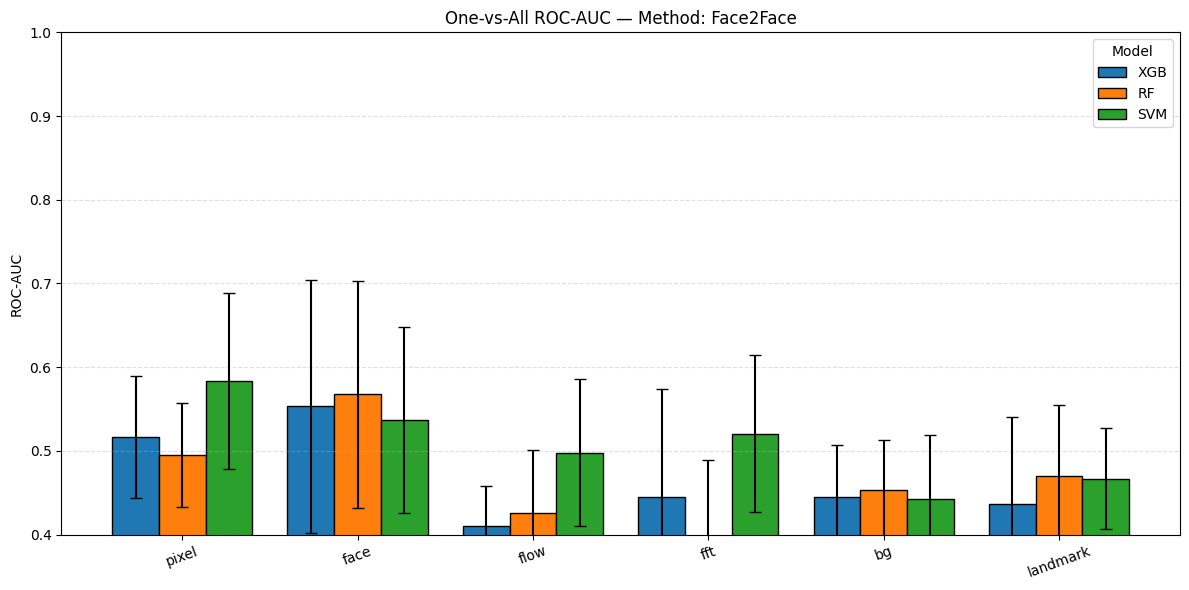

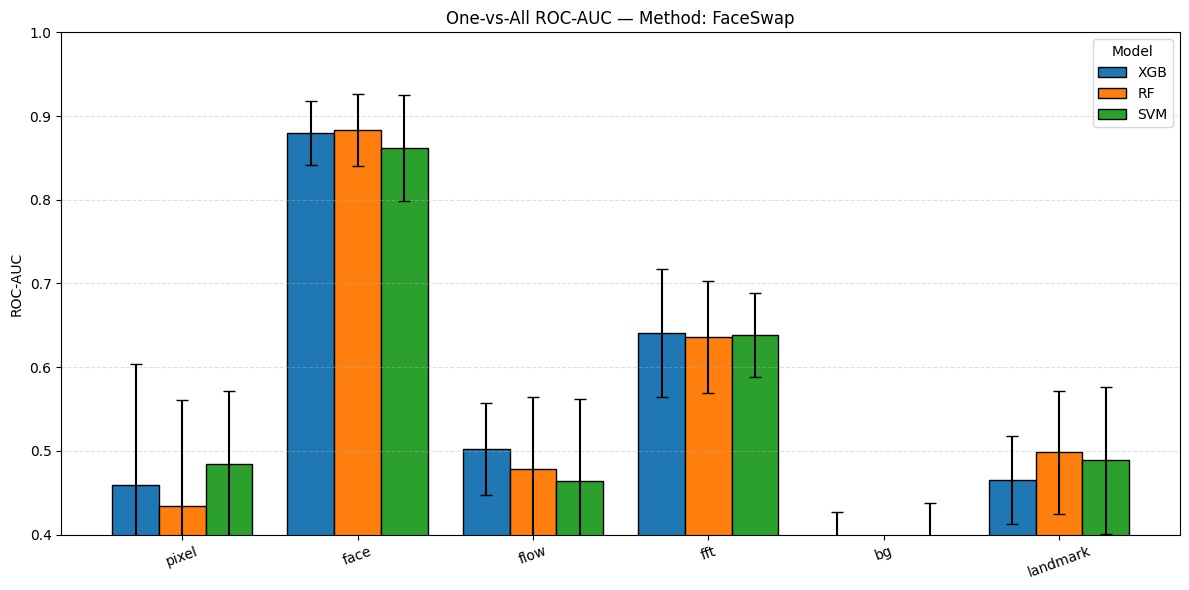

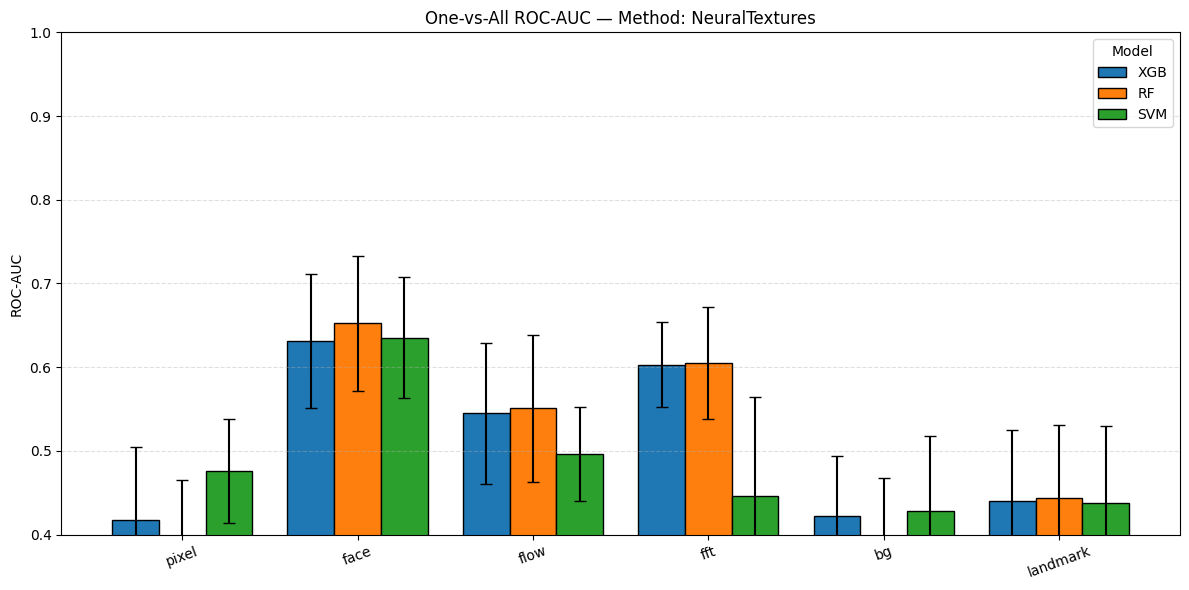

In [78]:
plot_method_bars(df)


Run binary classification - one-vs-one for all possiable combinations

In [79]:
from itertools import combinations

pairs = list(combinations(methods, 2))
print(pairs)

[('Deepfakes', 'Face2Face'), ('Deepfakes', 'FaceSwap'), ('Deepfakes', 'NeuralTextures'), ('Face2Face', 'FaceSwap'), ('Face2Face', 'NeuralTextures'), ('FaceSwap', 'NeuralTextures')]


In [80]:
import numpy as np

def get_pair_data(X, y, class_a, class_b):
    y = np.array(y)

    idx = np.where((y == class_a) | (y == class_b))[0]
    X_pair = X[idx]

    # binary labels: class_b = 1, class_a = 0
    y_pair = (y[idx] == class_b).astype(int)

    return X_pair, y_pair


In [81]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

try:
    from xgboost import XGBClassifier
    has_xgb = True
except ImportError:
    has_xgb = False

models = {
    "RF": RandomForestClassifier(
        n_estimators=150,
        random_state=0,
        n_jobs=-1
    ),
    "SVM": SVC(
        kernel="rbf",
        C=1.0
    )
}

if has_xgb:
    models["XGB"] = XGBClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        tree_method="hist",
        random_state=0
    )


In [82]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

results = []

for c1, c2 in pairs:
    for feat_name, X_all in feature_sets.items():

        X_pair, y_pair = get_pair_data(X_all, y, c1, c2)

        for model_name, clf in models.items():
            acc = cross_val_score(
                clf, X_pair, y_pair,
                cv=cv,
                scoring="accuracy",
                n_jobs=-1
            )

            auc = cross_val_score(
                clf, X_pair, y_pair,
                cv=cv,
                scoring="roc_auc",
                n_jobs=-1
            )

            results.append({
                "pair": f"{c1} vs {c2}",
                "features": feat_name,
                "model": model_name,
                "acc_mean": acc.mean(),
                "acc_std": acc.std(),
                "auc_mean": auc.mean(),
                "auc_std": auc.std()
            })

            print(
                f"{c1:15s} vs {c2:15s} | "
                f"{feat_name:7s} | {model_name:4s} → "
                f"ACC {acc.mean():.3f} | AUC {auc.mean():.3f}"
            )


Deepfakes       vs Face2Face       | fft     | RF   → ACC 0.546 | AUC 0.550
Deepfakes       vs Face2Face       | fft     | SVM  → ACC 0.571 | AUC 0.597
Deepfakes       vs Face2Face       | fft     | XGB  → ACC 0.521 | AUC 0.534
Deepfakes       vs Face2Face       | landmark | RF   → ACC 0.479 | AUC 0.506
Deepfakes       vs Face2Face       | landmark | SVM  → ACC 0.492 | AUC 0.556
Deepfakes       vs Face2Face       | landmark | XGB  → ACC 0.500 | AUC 0.511
Deepfakes       vs Face2Face       | flow    | RF   → ACC 0.462 | AUC 0.467
Deepfakes       vs Face2Face       | flow    | SVM  → ACC 0.571 | AUC 0.593
Deepfakes       vs Face2Face       | flow    | XGB  → ACC 0.467 | AUC 0.470
Deepfakes       vs Face2Face       | face    | RF   → ACC 0.500 | AUC 0.543
Deepfakes       vs Face2Face       | face    | SVM  → ACC 0.425 | AUC 0.399
Deepfakes       vs Face2Face       | face    | XGB  → ACC 0.525 | AUC 0.494
Deepfakes       vs Face2Face       | bg      | RF   → ACC 0.567 | AUC 0.571
Deepfakes

Plot the results

In [83]:
import numpy as np
import matplotlib.pyplot as plt

def plot_pairwise_bars(df, metric="auc_mean", title=None):
    """
    metric: 'acc_mean' or 'auc_mean'
    """

    pairs = df["pair"].unique()
    models = df["model"].unique()

    n_pairs = len(pairs)
    n_models = len(models)

    bar_width = 0.18
    x = np.arange(n_pairs)

    plt.figure(figsize=(14, 6))

    for i, model in enumerate(models):
        values = [
            df[(df["pair"] == p) & (df["model"] == model)][metric].values[0]
            for p in pairs
        ]

        plt.bar(
            x + i * bar_width,
            values,
            width=bar_width,
            label=model
        )

    plt.xticks(
        x + bar_width * (n_models - 1) / 2,
        pairs,
        rotation=30,
        ha="right"
    )

    plt.ylabel(metric.replace("_mean", "").upper())
    plt.xlabel("Method vs Method")

    if title:
        plt.title(title)

    plt.legend(title="Model")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


In [84]:
df = pd.DataFrame(results)


Pairwise classification per classification algorithm - AUC ROC

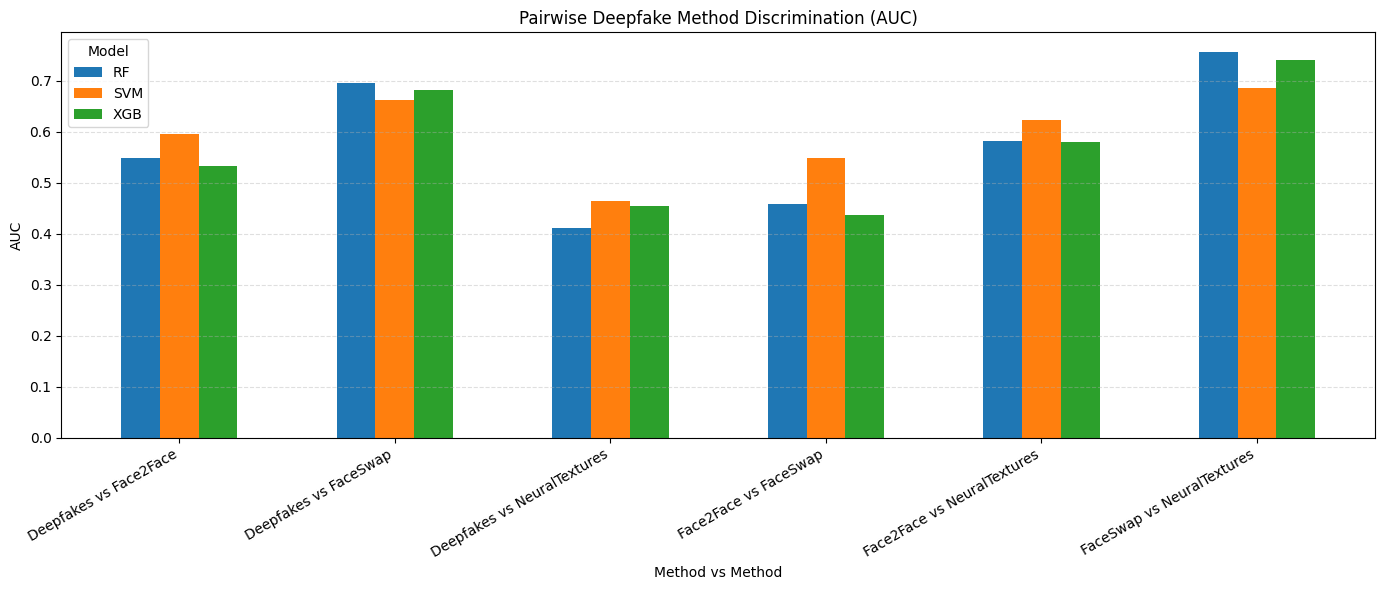

In [85]:
plot_pairwise_bars(
    df,
    metric="auc_mean",
    title="Pairwise Deepfake Method Discrimination (AUC)"
)


Pairwise classification per classification algorithm - Accuracy

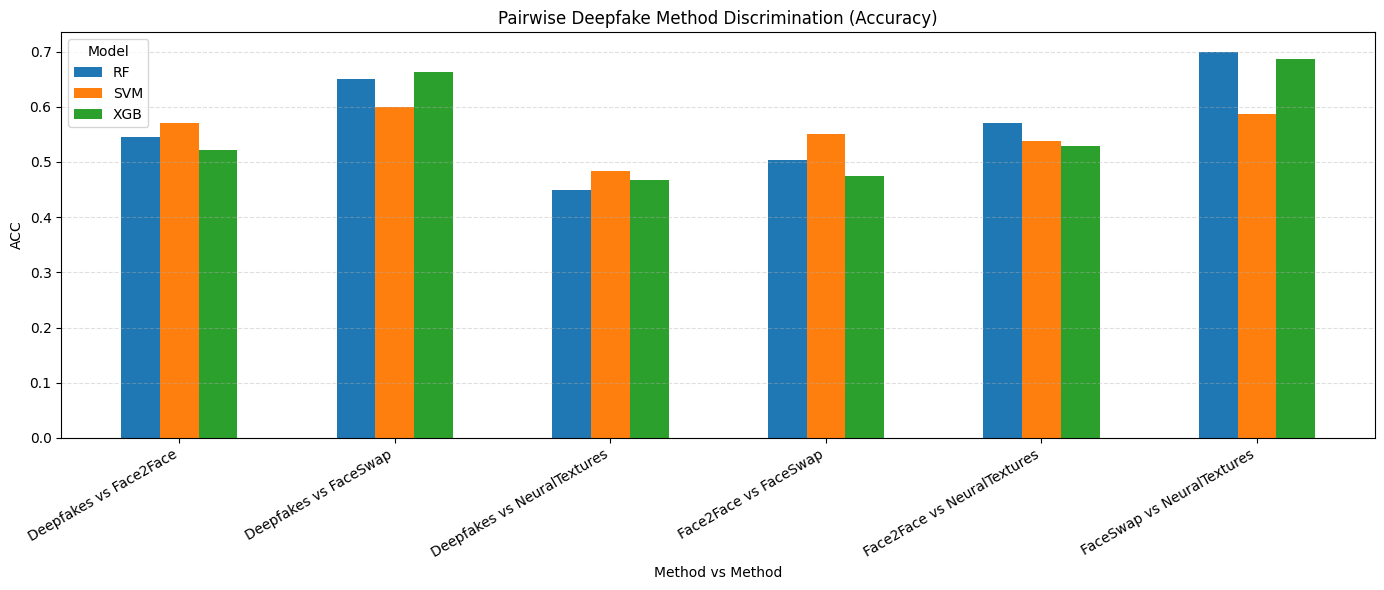

In [86]:
plot_pairwise_bars(
    df,
    metric="acc_mean",
    title="Pairwise Deepfake Method Discrimination (Accuracy)"
)


Pairwise classification per classification algorithm **per feature** - AUC ROC

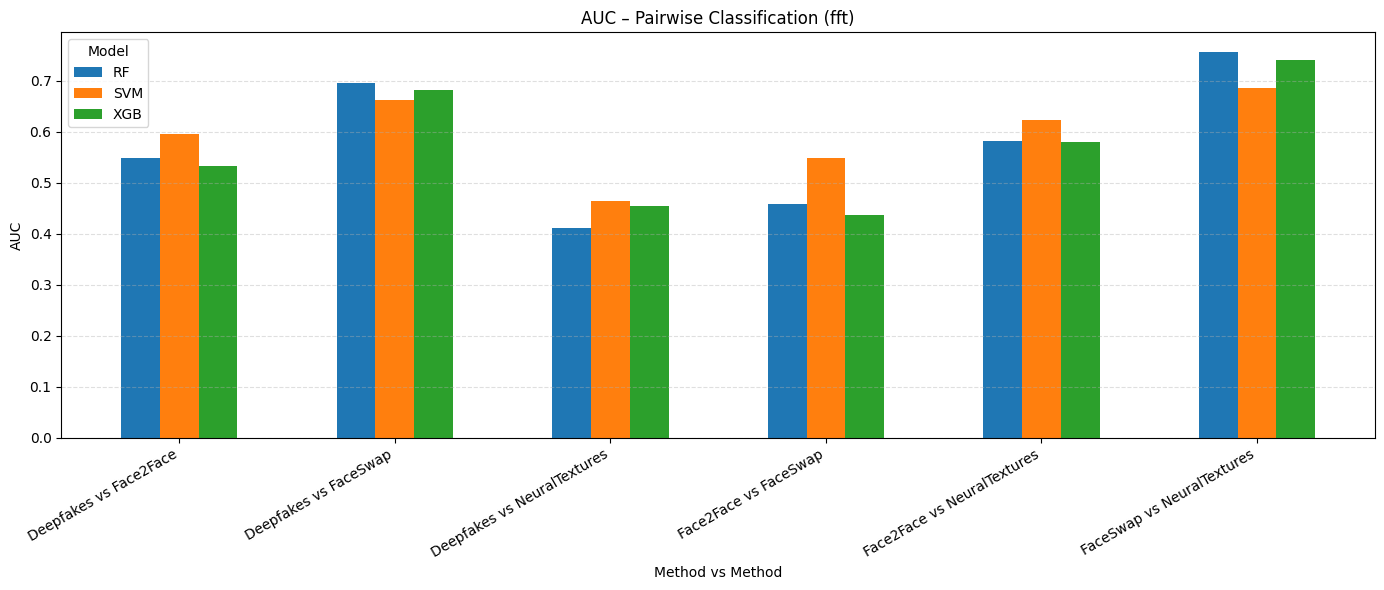

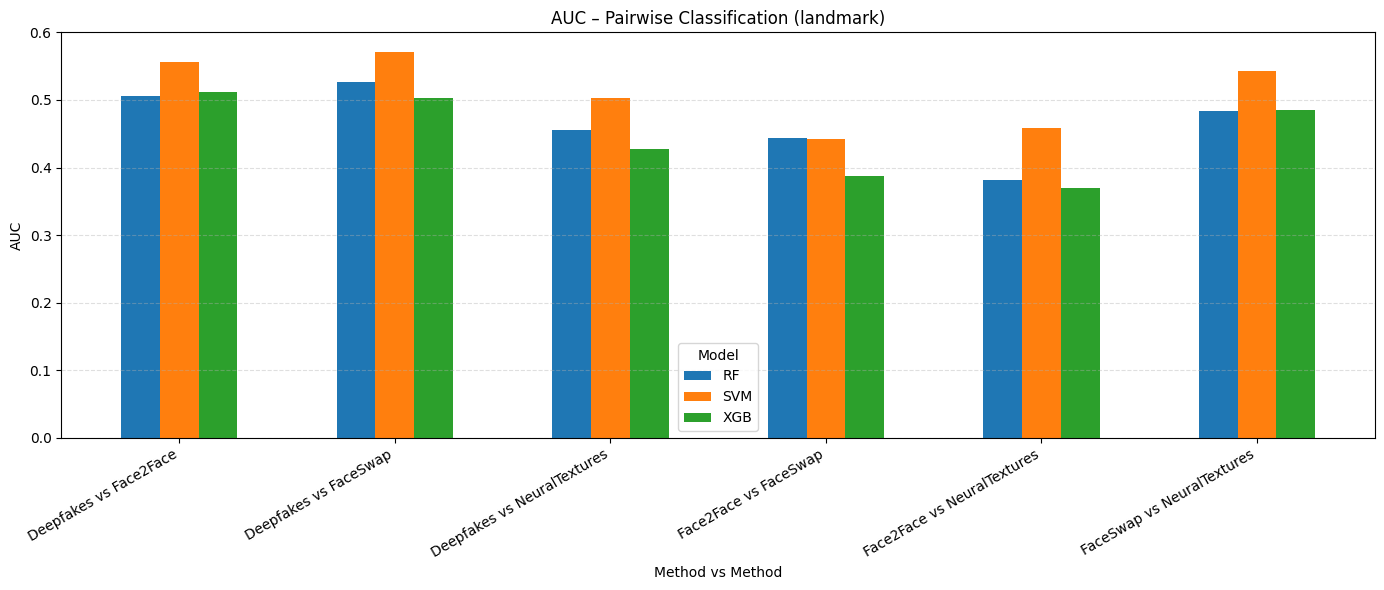

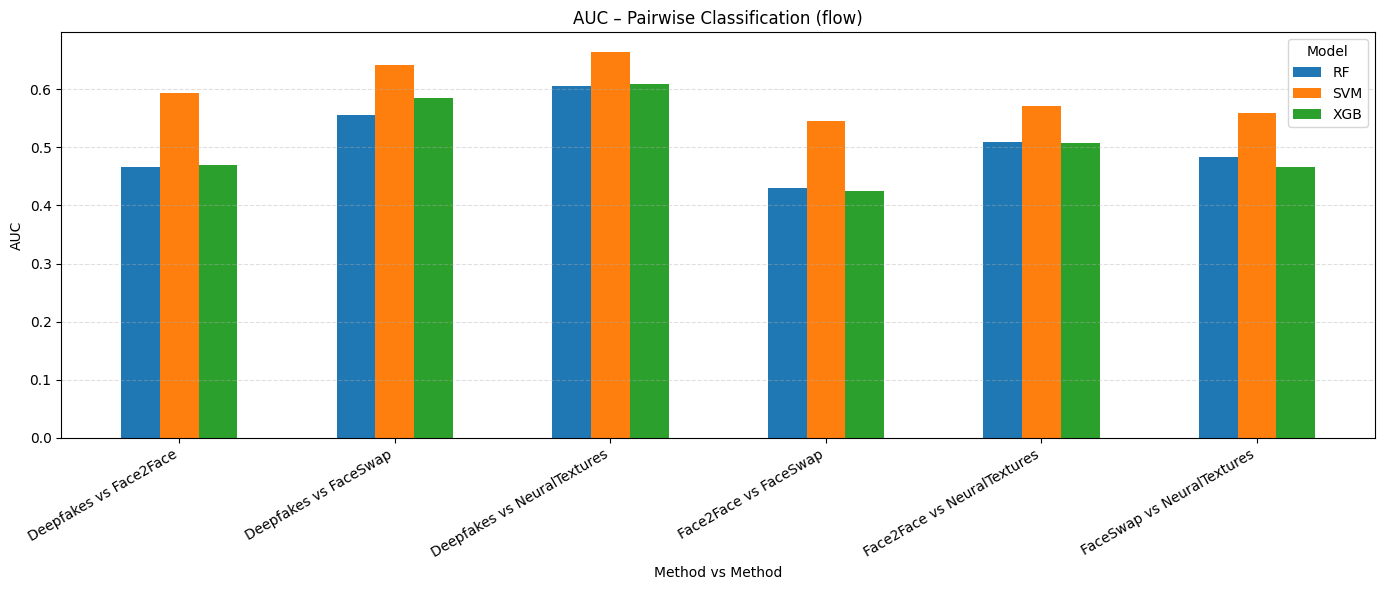

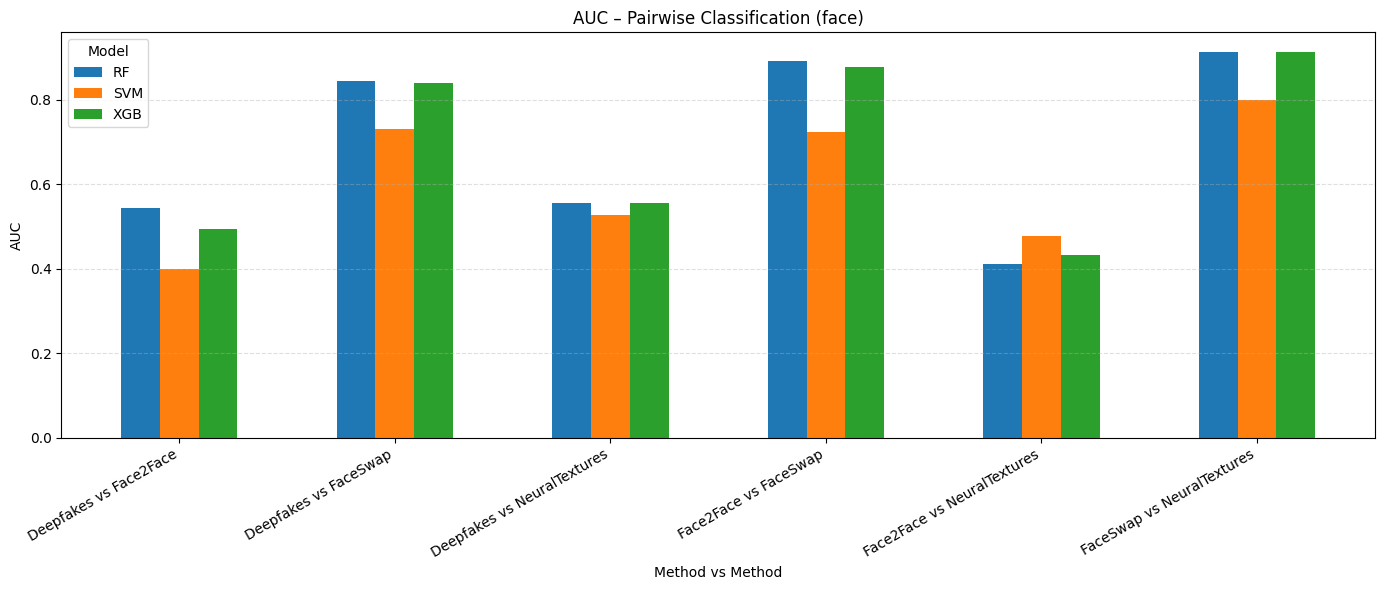

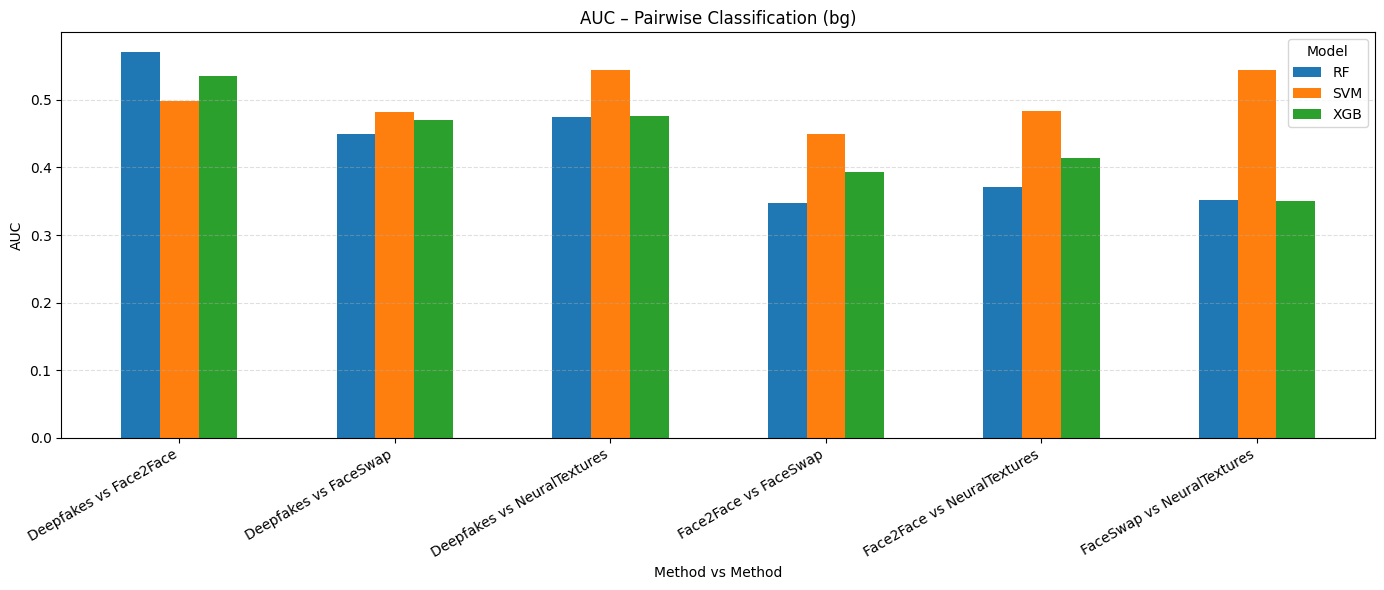

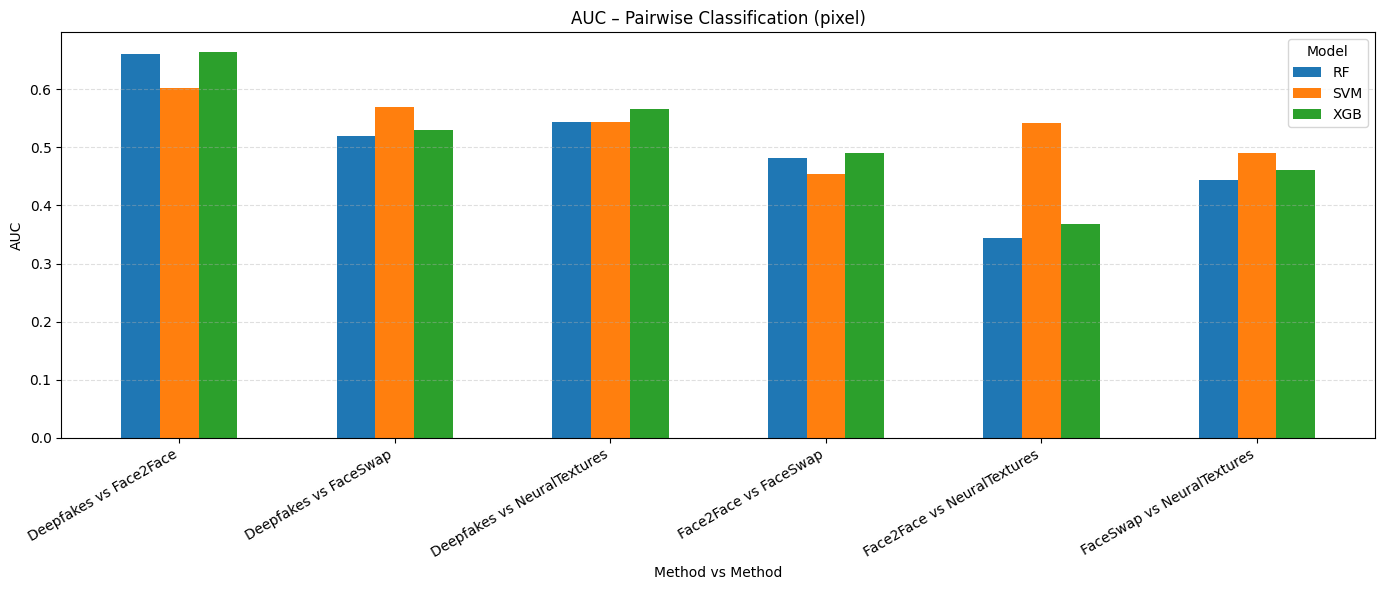

In [87]:
for feat in df["features"].unique():
    plot_pairwise_bars(
        df[df["features"] == feat],
        metric="auc_mean",
        title=f"AUC – Pairwise Classification ({feat})"
    )


Use only Random Forest - Since has the best performance among tested algorithms

In [88]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=0,
    n_jobs=-1
)


In [89]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import pandas as pd

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

rf_results = []

for c1, c2 in pairs:
    for feat_name, X_all in feature_sets.items():

        X_pair, y_pair = get_pair_data(X_all, y, c1, c2)

        acc = cross_val_score(
            rf, X_pair, y_pair,
            cv=cv,
            scoring="accuracy",
            n_jobs=-1
        )

        auc = cross_val_score(
            rf, X_pair, y_pair,
            cv=cv,
            scoring="roc_auc",
            n_jobs=-1
        )

        rf_results.append({
            "pair": f"{c1} vs {c2}",
            "features": feat_name,
            "acc_mean": acc.mean(),
            "acc_std": acc.std(),
            "auc_mean": auc.mean(),
            "auc_std": auc.std()
        })

        print(
            f"{c1:15s} vs {c2:15s} | "
            f"{feat_name:7s} → "
            f"ACC {acc.mean():.3f} | AUC {auc.mean():.3f}"
        )

rf_df = pd.DataFrame(rf_results)


Deepfakes       vs Face2Face       | fft     → ACC 0.533 | AUC 0.549
Deepfakes       vs Face2Face       | landmark → ACC 0.517 | AUC 0.513
Deepfakes       vs Face2Face       | flow    → ACC 0.483 | AUC 0.474
Deepfakes       vs Face2Face       | face    → ACC 0.500 | AUC 0.527
Deepfakes       vs Face2Face       | bg      → ACC 0.571 | AUC 0.573
Deepfakes       vs Face2Face       | pixel   → ACC 0.629 | AUC 0.655
Deepfakes       vs FaceSwap        | fft     → ACC 0.662 | AUC 0.694
Deepfakes       vs FaceSwap        | landmark → ACC 0.504 | AUC 0.529
Deepfakes       vs FaceSwap        | flow    → ACC 0.567 | AUC 0.562
Deepfakes       vs FaceSwap        | face    → ACC 0.758 | AUC 0.848
Deepfakes       vs FaceSwap        | bg      → ACC 0.492 | AUC 0.439
Deepfakes       vs FaceSwap        | pixel   → ACC 0.529 | AUC 0.528
Deepfakes       vs NeuralTextures  | fft     → ACC 0.446 | AUC 0.421
Deepfakes       vs NeuralTextures  | landmark → ACC 0.475 | AUC 0.443
Deepfakes       vs NeuralTextur

In [90]:
import numpy as np
import matplotlib.pyplot as plt

def plot_rf_features(df, metric="auc_mean", title=None):
    pairs = df["pair"].unique()
    features = df["features"].unique()

    n_pairs = len(pairs)
    n_feats = len(features)

    bar_width = 0.14
    x = np.arange(n_pairs)

    plt.figure(figsize=(14, 6))

    for i, feat in enumerate(features):
        values = [
            df[(df["pair"] == p) & (df["features"] == feat)][metric].values[0]
            for p in pairs
        ]

        plt.bar(
            x + i * bar_width,
            values,
            width=bar_width,
            label=feat
        )

    plt.xticks(
        x + bar_width * (n_feats - 1) / 2,
        pairs,
        rotation=30,
        ha="right"
    )

    plt.ylabel(metric.replace("_mean", "").upper())
    plt.xlabel("Method vs Method")

    if title:
        plt.title(title)

    plt.legend(title="Feature Set")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()


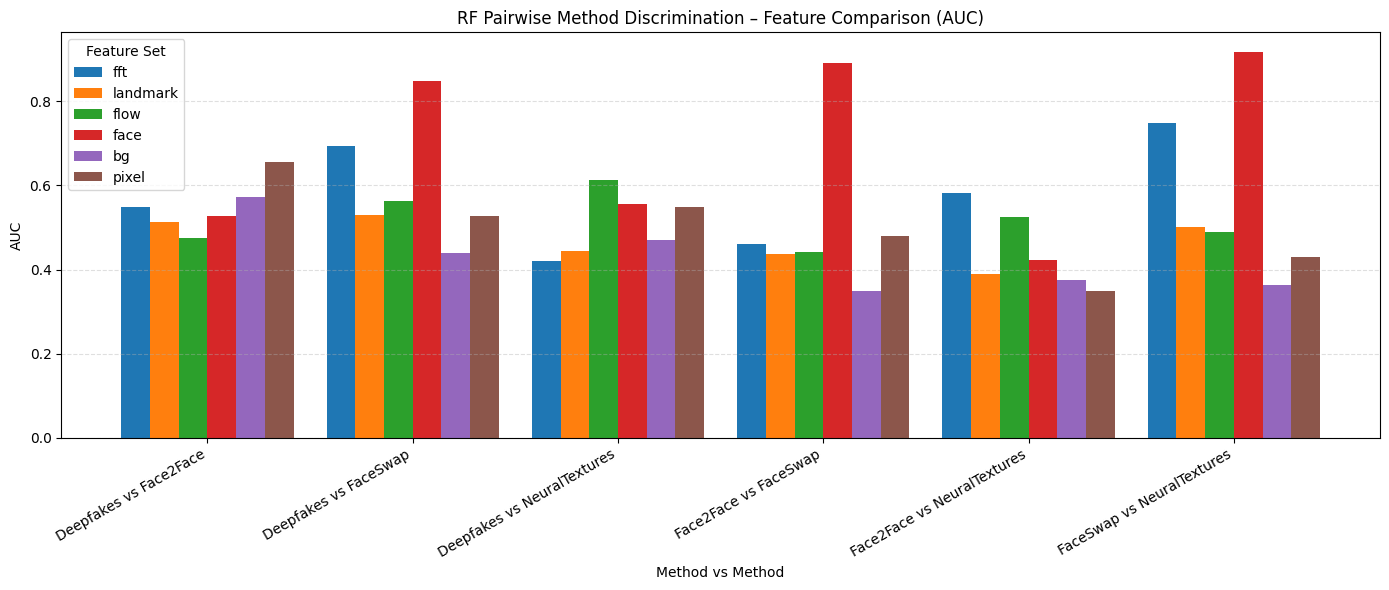

In [91]:
plot_rf_features(
    rf_df,
    metric="auc_mean",
    title="RF Pairwise Method Discrimination – Feature Comparison (AUC)"
)


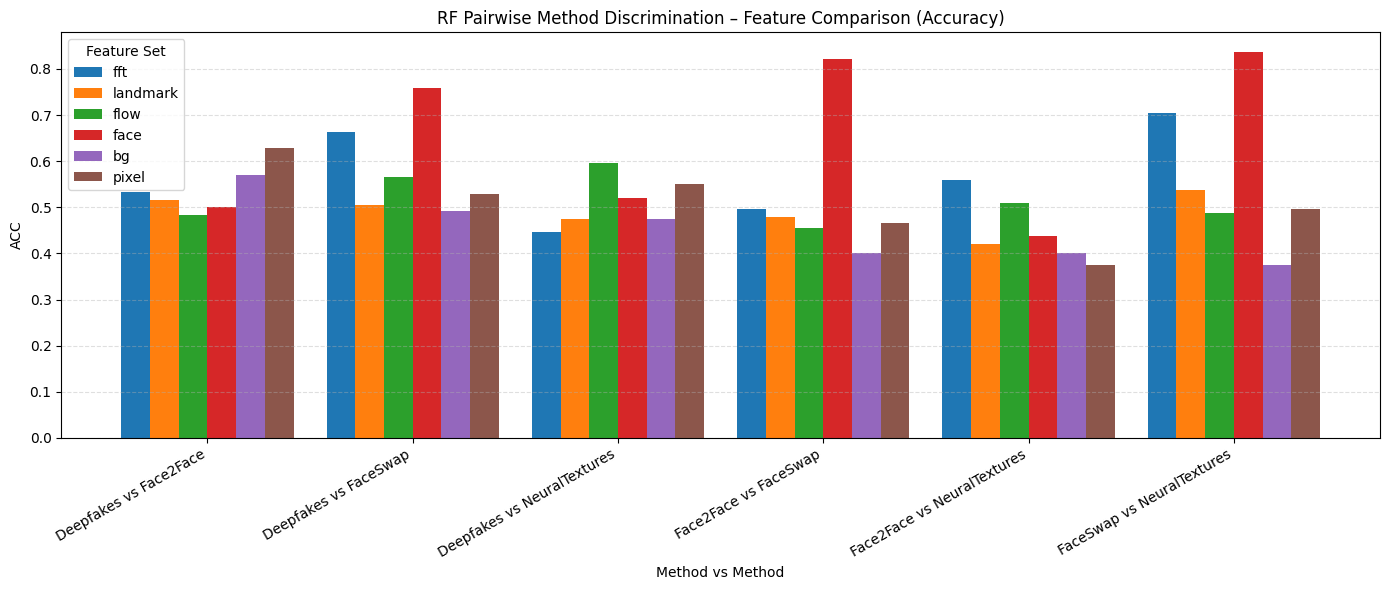

In [92]:
plot_rf_features(
    rf_df,
    metric="acc_mean",
    title="RF Pairwise Method Discrimination – Feature Comparison (Accuracy)"
)


Plot 2D seperation between different methods and features using t-SNE and PCA

In [93]:
import numpy as np

def get_pair_data_only(X, y, c1, c2):
    y = np.array(y)
    idx = np.where((y == c1) | (y == c2))[0]
    return X[idx], y[idx]


In [94]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_pairwise_pca(c1, c2, feature_sets, y):
    plt.figure(figsize=(7, 6))

    markers = {c1: "o", c2: "s"}

    for feat_name, X_all in feature_sets.items():
        X_pair, y_pair = get_pair_data_only(X_all, y, c1, c2)

        X_2d = PCA(n_components=2).fit_transform(X_pair)

        for method in [c1, c2]:
            idx = (y_pair == method)
            plt.scatter(
                X_2d[idx, 0],
                X_2d[idx, 1],
                label=f"{feat_name} – {method}",
                marker=markers[method],
                alpha=0.6
            )

    plt.title(f"PCA: {c1} vs {c2}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


In [95]:
from sklearn.manifold import TSNE

def plot_pairwise_tsne(c1, c2, feature_sets, y):
    plt.figure(figsize=(7, 6))

    markers = {c1: "o", c2: "s"}

    for feat_name, X_all in feature_sets.items():
        X_pair, y_pair = get_pair_data_only(X_all, y, c1, c2)

        X_2d = TSNE(
            n_components=2,
            perplexity=30,
            learning_rate="auto",
            init="pca",
            random_state=0
        ).fit_transform(X_pair)

        for method in [c1, c2]:
            idx = (y_pair == method)
            plt.scatter(
                X_2d[idx, 0],
                X_2d[idx, 1],
                label=f"{feat_name} – {method}",
                marker=markers[method],
                alpha=0.6
            )

    plt.title(f"t-SNE: {c1} vs {c2}")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


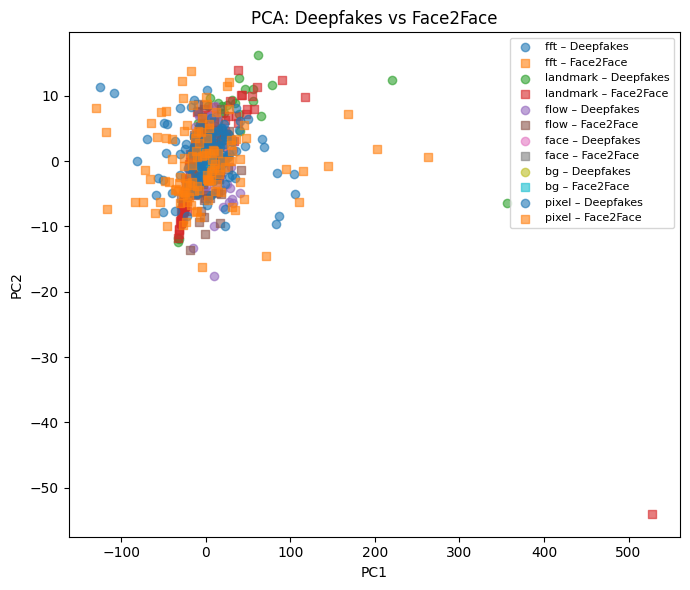

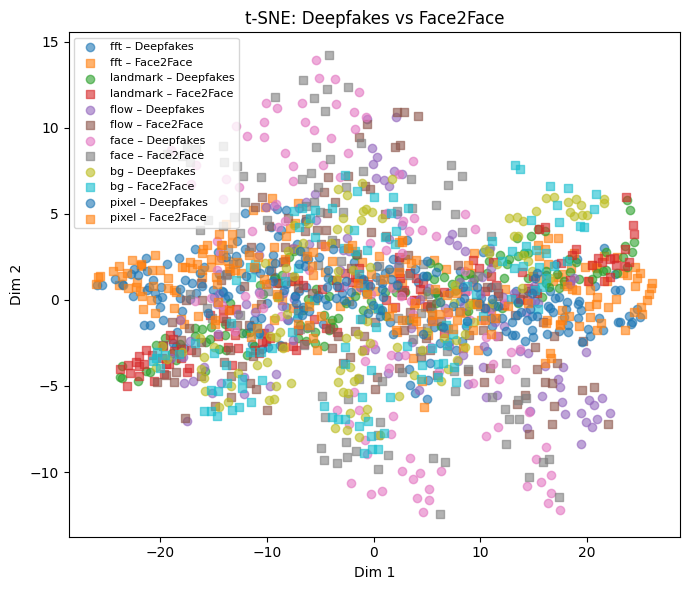

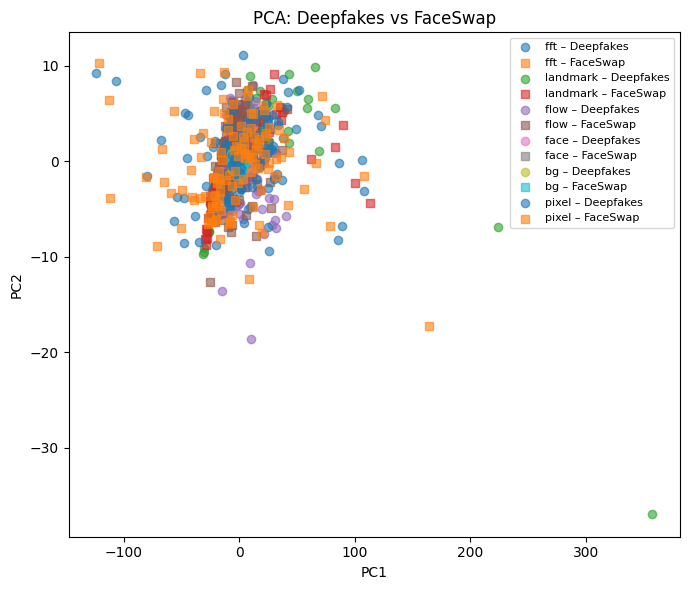

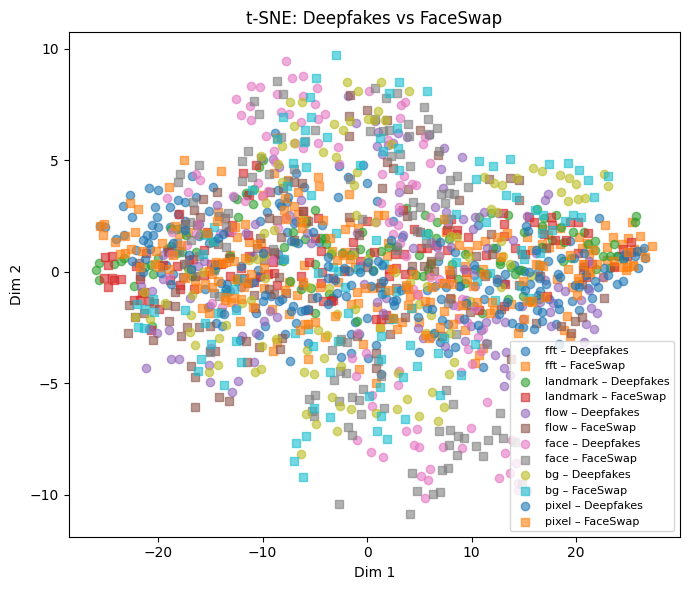

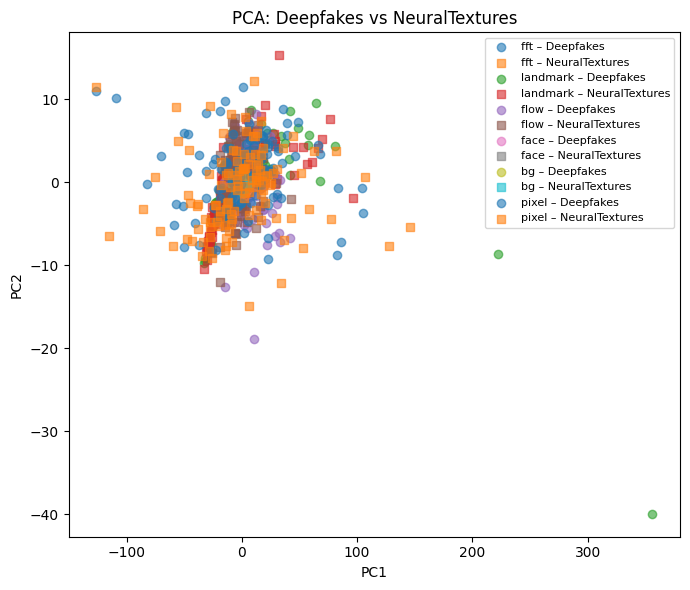

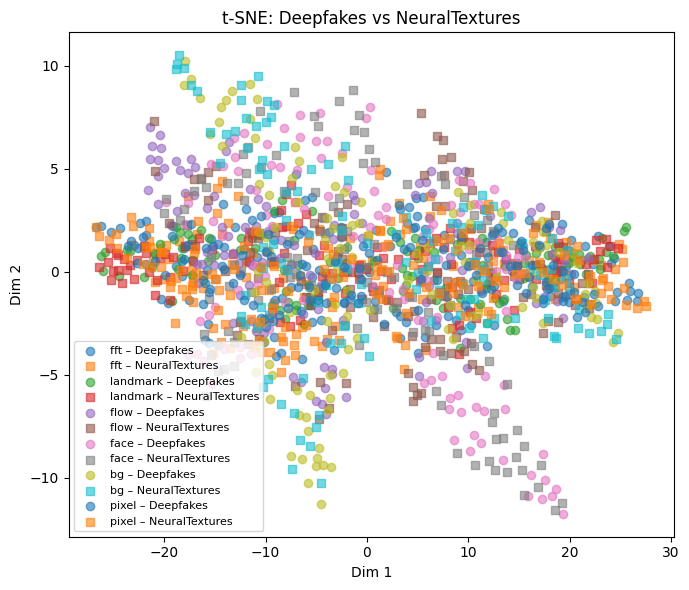

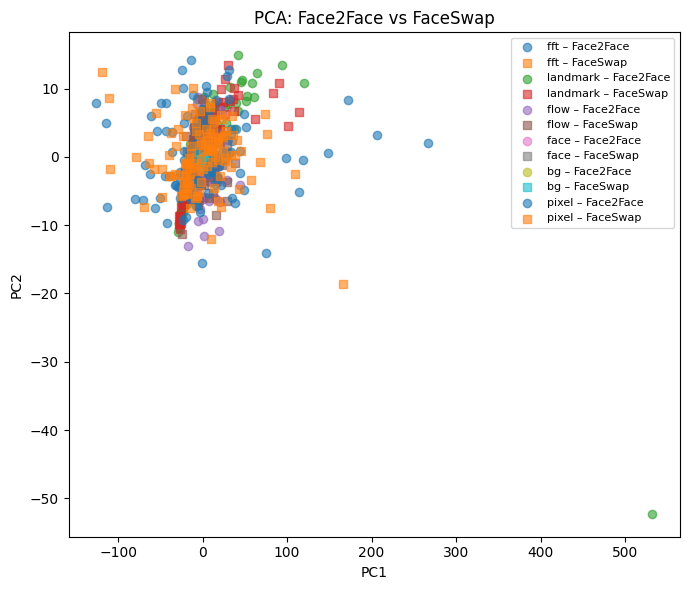

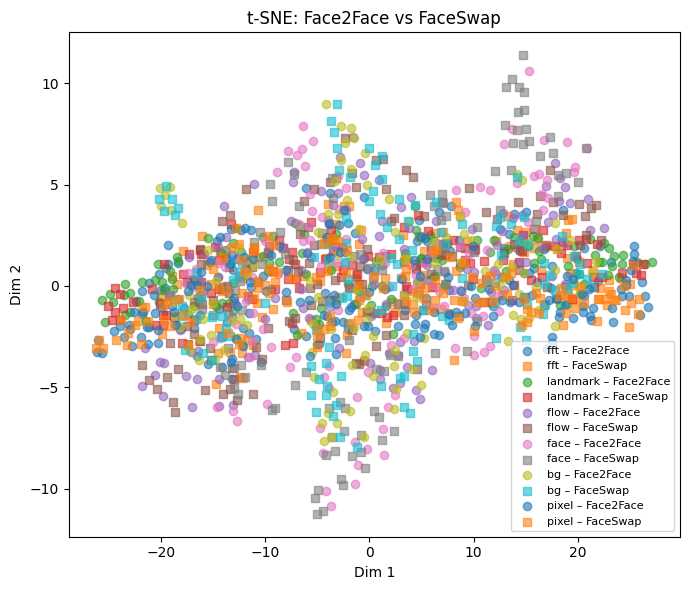

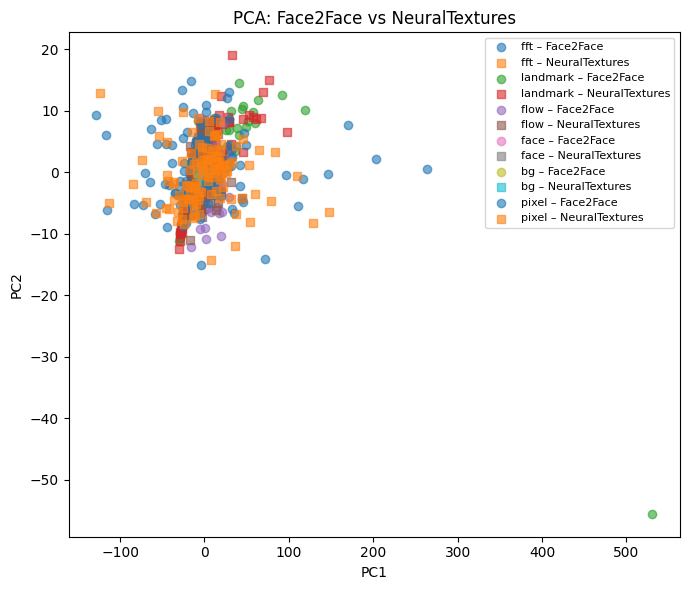

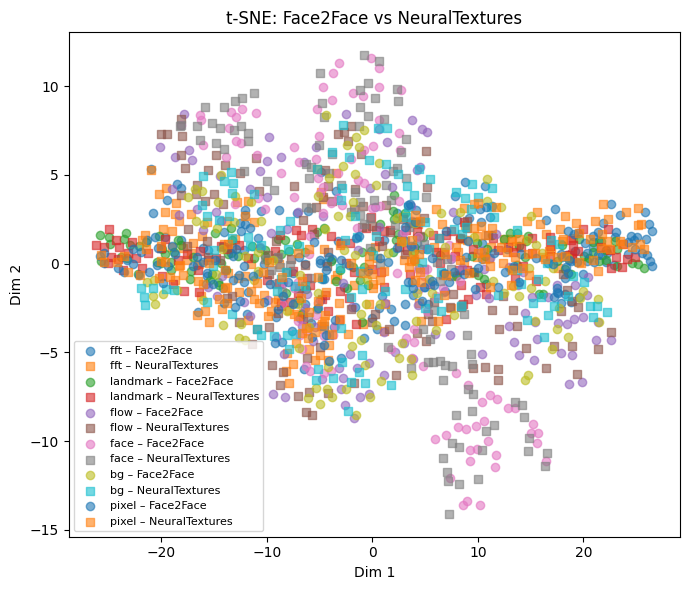

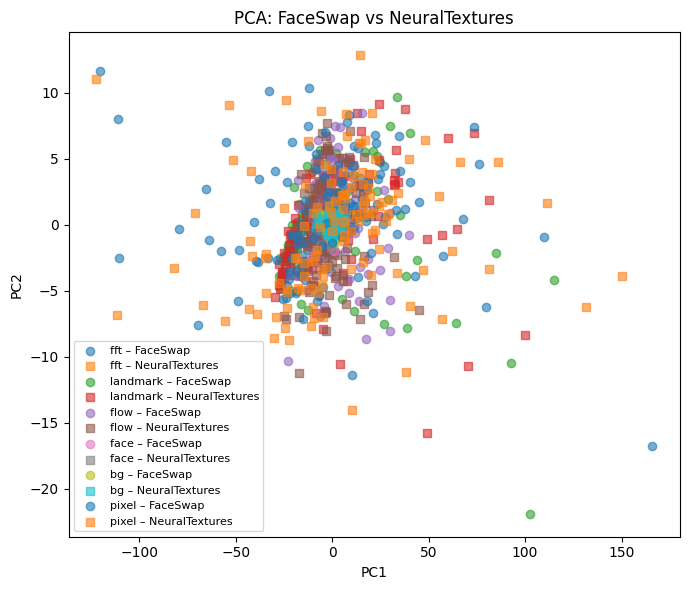

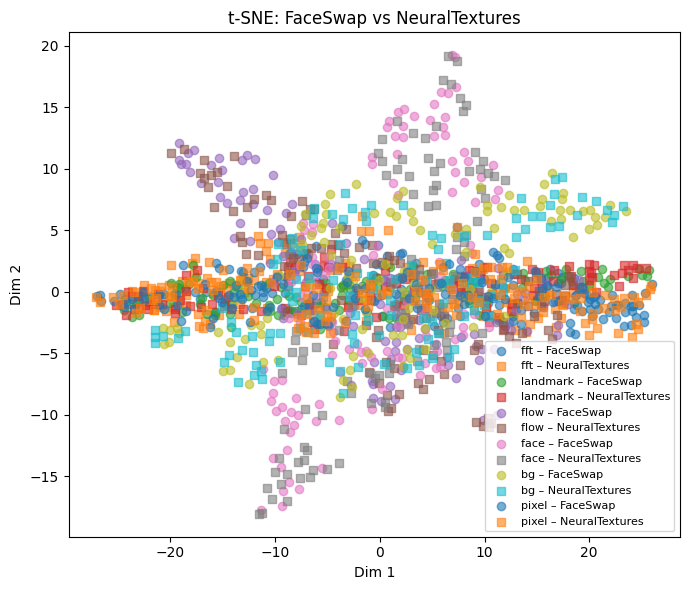

In [96]:
from itertools import combinations

pairs = list(combinations(methods, 2))

for c1, c2 in pairs:
    plot_pairwise_pca(c1, c2, feature_sets, y)
    plot_pairwise_tsne(c1, c2, feature_sets, y)


Evaluate on random forest using the 2 best features we saw - Face embeddings,FFT and a concation of face + FFT. Apply scailing to make sure that both methods are on the same scale.

In [97]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

def eval_pairwise_auc_rf(X, y, pairs):
    rf = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1)
    clf = make_pipeline(StandardScaler(), rf)

    out = []
    for c1, c2 in pairs:
        idx = np.where((y == c1) | (y == c2))[0]
        Xp = X[idx]
        yp = (y[idx] == c2).astype(int)

        auc = cross_val_score(clf, Xp, yp, cv=cv, scoring="roc_auc", n_jobs=-1)
        out.append((f"{c1} vs {c2}", auc.mean(), auc.std()))
    return out


In [98]:
X_face = X_face_embed
X_fft  = X_fft

X_concat_face_fft = np.concatenate([X_face, X_fft], axis=1)


In [99]:
res_fft   = eval_pairwise_auc_rf(X_fft, y, pairs)
res_face  = eval_pairwise_auc_rf(X_face, y, pairs)
res_combo = eval_pairwise_auc_rf(X_concat_face_fft, y, pairs)

print("FFT:", res_fft)
print("Face:", res_face)
print("Face+FFT:", res_combo)


FFT: [('Deepfakes vs Face2Face', np.float64(0.5486111111111112), np.float64(0.09344084829254083)), ('Deepfakes vs FaceSwap', np.float64(0.6944444444444444), np.float64(0.12059163246671659)), ('Deepfakes vs NeuralTextures', np.float64(0.4208333333333333), np.float64(0.10692866045137724)), ('Face2Face vs FaceSwap', np.float64(0.46215277777777775), np.float64(0.07766376191714806)), ('Face2Face vs NeuralTextures', np.float64(0.5822916666666667), np.float64(0.05256834359628227)), ('FaceSwap vs NeuralTextures', np.float64(0.7493055555555557), np.float64(0.06687611773613053))]
Face: [('Deepfakes vs Face2Face', np.float64(0.5274305555555555), np.float64(0.08640811794746037)), ('Deepfakes vs FaceSwap', np.float64(0.8482638888888889), np.float64(0.0632297291603511)), ('Deepfakes vs NeuralTextures', np.float64(0.55625), np.float64(0.11664599684621378)), ('Face2Face vs FaceSwap', np.float64(0.8895833333333334), np.float64(0.07211530547637315)), ('Face2Face vs NeuralTextures', np.float64(0.42291666

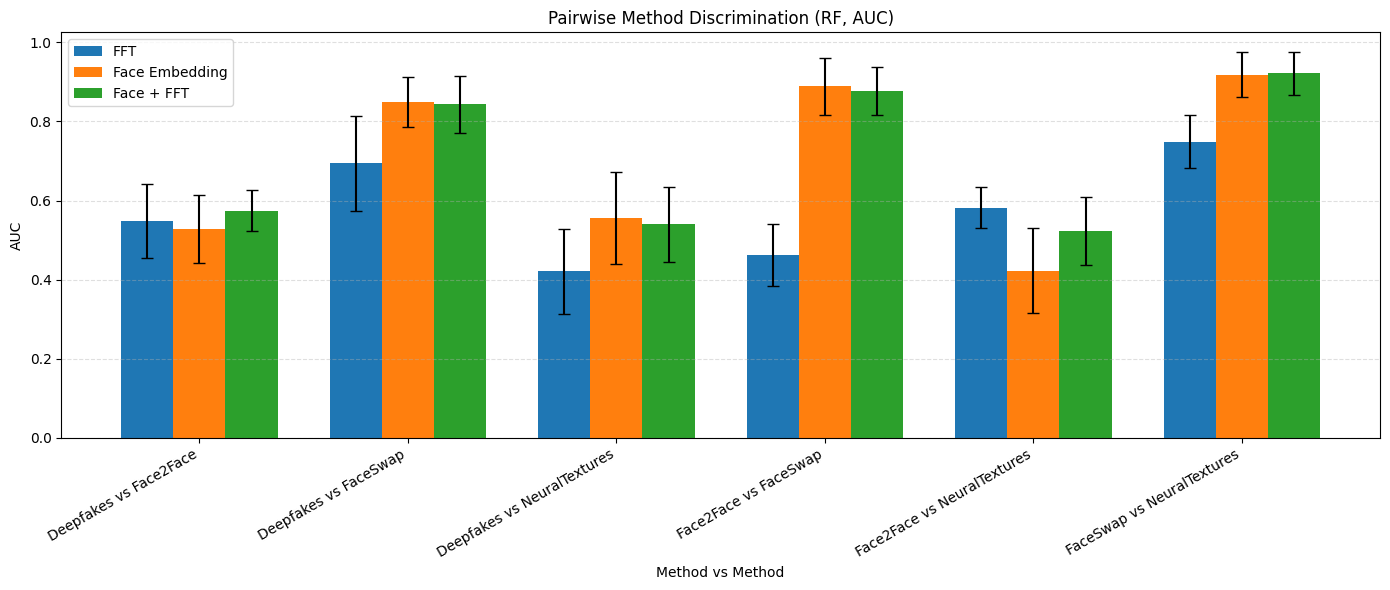

In [100]:
import matplotlib.pyplot as plt

pairs = [x[0] for x in res_fft]
x = np.arange(len(pairs))
width = 0.25

fft_mean = [x[1] for x in res_fft]
fft_std  = [x[2] for x in res_fft]

face_mean = [x[1] for x in res_face]
face_std  = [x[2] for x in res_face]

combo_mean = [x[1] for x in res_combo]
combo_std  = [x[2] for x in res_combo]


plt.figure(figsize=(14, 6))

plt.bar(x - width, fft_mean, width,
        yerr=fft_std, capsize=4, label="FFT")

plt.bar(x, face_mean, width,
        yerr=face_std, capsize=4, label="Face Embedding")

plt.bar(x + width, combo_mean, width,
        yerr=combo_std, capsize=4, label="Face + FFT")

plt.xticks(x, pairs, rotation=30, ha="right")
plt.ylabel("AUC")
plt.xlabel("Method vs Method")
plt.title("Pairwise Method Discrimination (RF, AUC)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


Finally - Check performance for a 4 class classification task by feature and plot confusion matrix

In [102]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(
    n_estimators=300,
    random_state=0,
    n_jobs=-1
)


from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)

scoring = {
    "acc": "accuracy",
    "auc": "roc_auc_ovr",
    "auc_weighted": "roc_auc_ovr_weighted"

}


In [103]:
import numpy as np
import pandas as pd

results = []

for feat_name, X in feature_sets.items():
    scores = cross_validate(
        clf,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    results.append({
        "Feature": feat_name,
        "Accuracy_mean": scores["test_acc"].mean(),
        "Accuracy_std": scores["test_acc"].std(),
        "AUC_mean": scores["test_auc"].mean(),
        "AUC_std": scores["test_auc"].std()
    })

    print(
        f"{feat_name:10s} | "
        f"ACC = {scores['test_acc'].mean():.3f} ± {scores['test_acc'].std():.3f} | "
        f"AUC = {scores['test_auc'].mean():.3f} ± {scores['test_auc'].std():.3f}"
    )

df_multi = pd.DataFrame(results)
df_multi


fft        | ACC = 0.260 ± 0.063 | AUC = 0.543 ± 0.043
landmark   | ACC = 0.246 ± 0.057 | AUC = 0.476 ± 0.066
flow       | ACC = 0.256 ± 0.057 | AUC = 0.497 ± 0.048
face       | ACC = 0.388 ± 0.062 | AUC = 0.669 ± 0.045
bg         | ACC = 0.208 ± 0.046 | AUC = 0.399 ± 0.031
pixel      | ACC = 0.240 ± 0.049 | AUC = 0.478 ± 0.053


,Feature,Accuracy_mean,Accuracy_std,AUC_mean,AUC_std
0,fft,0.260417,0.062673,0.543258,0.042602
1,landmark,0.245833,0.056519,0.476186,0.066155
2,flow,0.256250,0.056711,0.496644,0.048322
3,face,0.387500,0.061942,0.669068,0.044892
4,bg,0.208333,0.045644,0.399190,0.031095
5,pixel,0.239583,0.048636,0.478038,0.052791


In [104]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_pred = cross_val_predict(clf, X_fft, y, cv=cv)
cm = confusion_matrix(y, y_pred, labels=methods)

cm


array([[30, 21, 24, 45],
       [25, 18, 47, 30],
       [20, 47, 42, 11],
       [44, 26, 15, 35]])

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_cm_normalized(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(6, 5))
    im = plt.imshow(cm_norm, interpolation="nearest")
    plt.colorbar(im, fraction=0.046)

    plt.xticks(range(len(labels)), labels, rotation=30, ha="right")
    plt.yticks(range(len(labels)), labels)

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)

    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(
                j, i, f"{cm_norm[i, j]:.2f}",
                ha="center", va="center",
                color="white" if cm_norm[i, j] > 0.5 else "black"
            )

    plt.tight_layout()
    plt.show()


CM for face embeddings

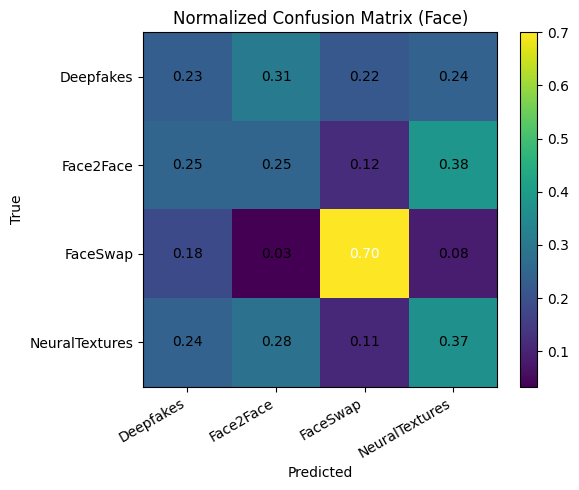

In [106]:
y_pred = cross_val_predict(clf, X_face_embed, y, cv=cv)
plot_cm_normalized(y, y_pred, methods, "Normalized Confusion Matrix (Face)")


CM for FFT

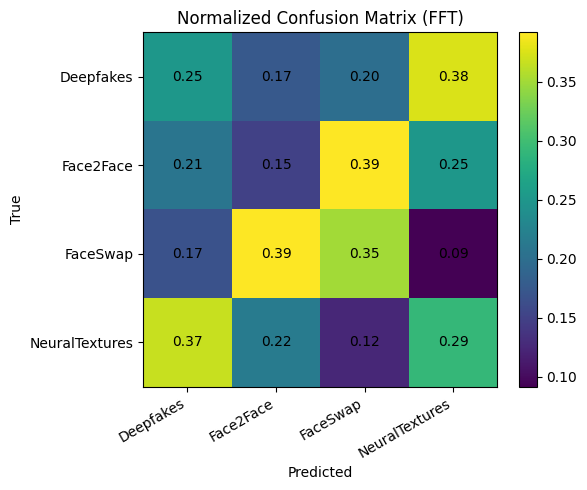

In [107]:
y_pred = cross_val_predict(clf, X_fft, y, cv=cv)
plot_cm_normalized(y, y_pred, methods, "Normalized Confusion Matrix (FFT)")
